파일 별 데이터 분포 분석

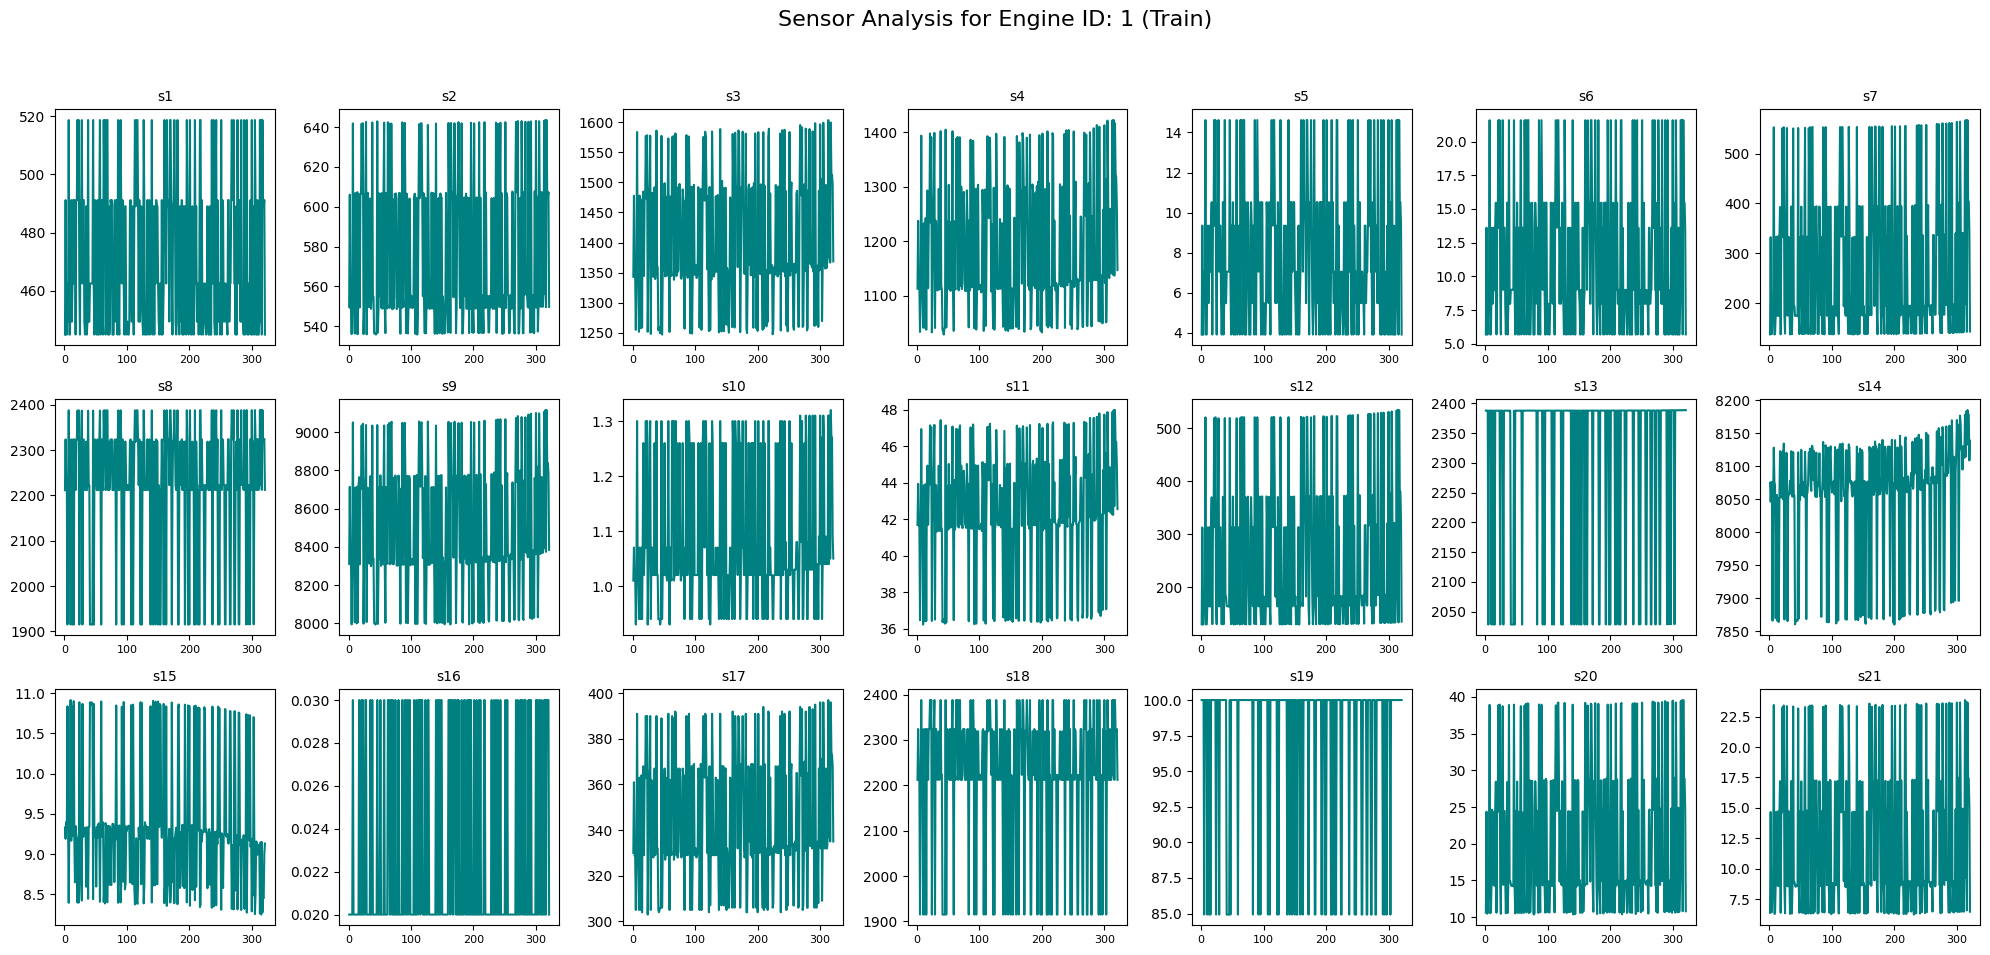

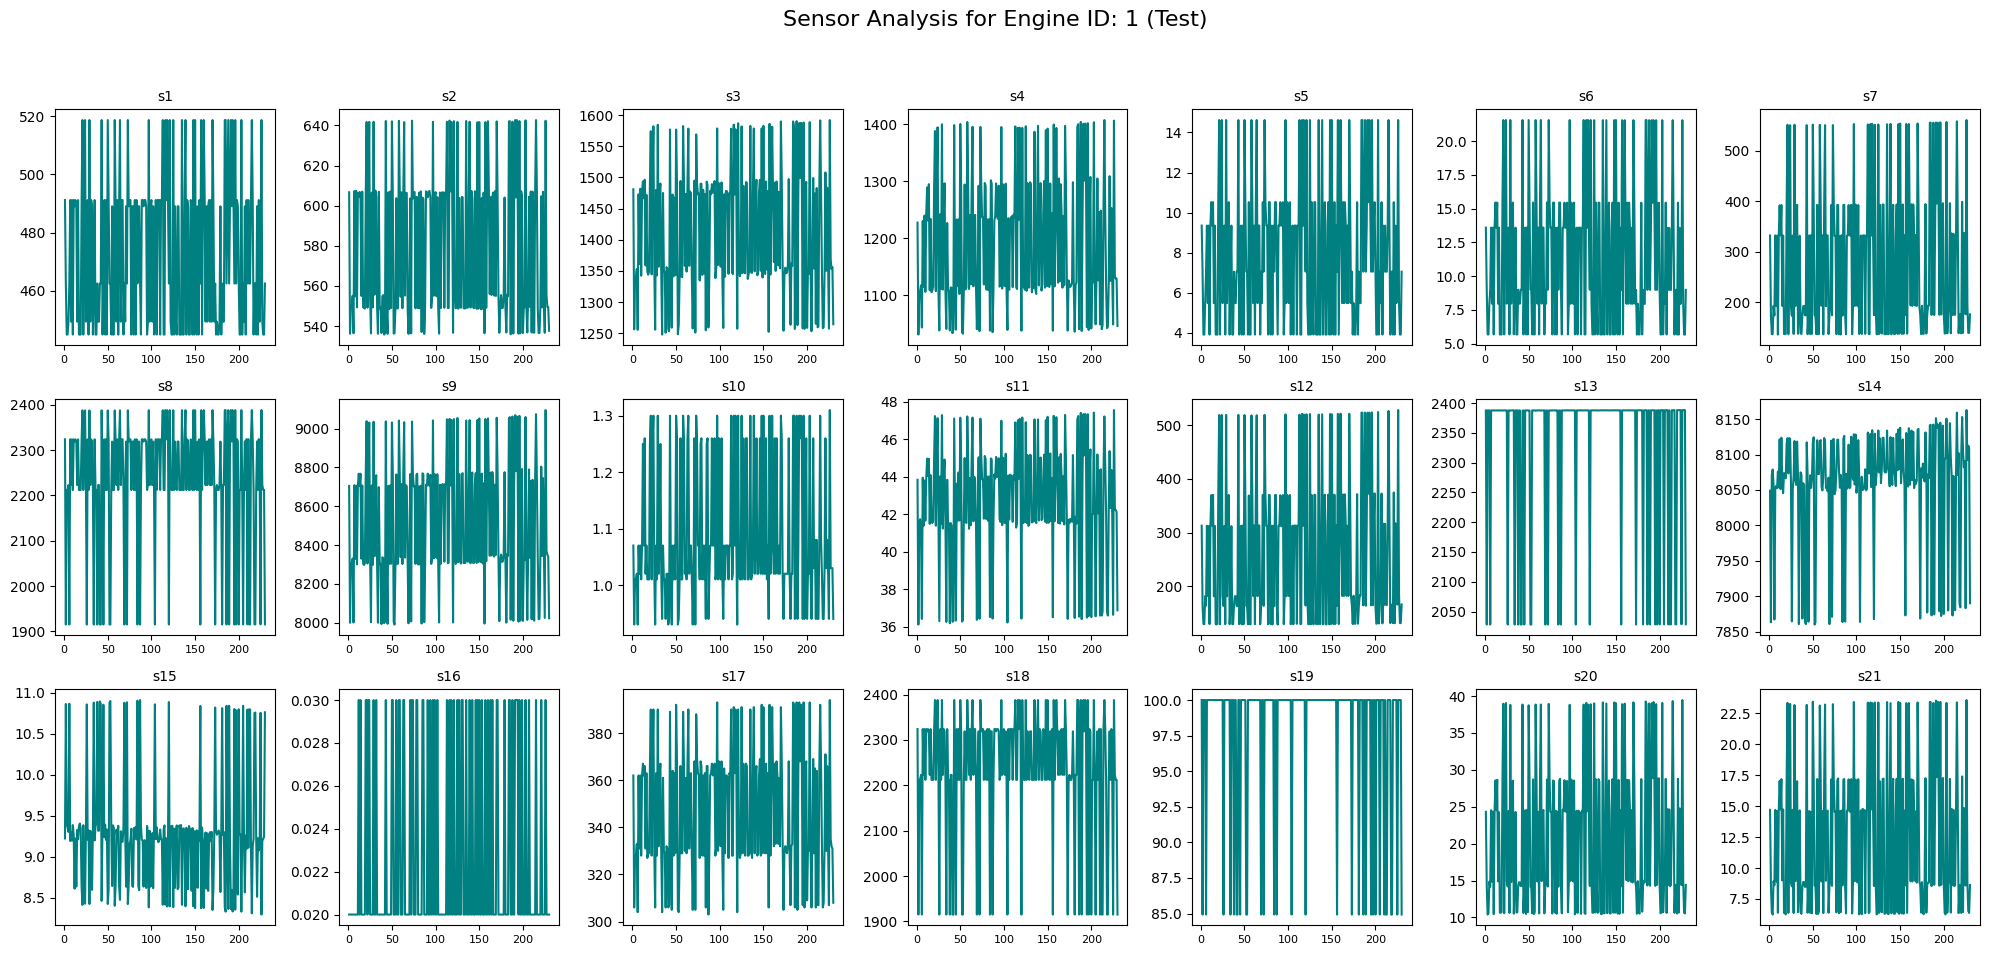

In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# 1. 경로 및 데이터 로드
base_path = "/Users/gyuminkang/Desktop/nasa/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData/"
columns = ["engine_id", "cycle"] + [f"setting{i}" for i in range(1, 4)] + [f"s{i}" for i in range(1, 22)]

df_train = pd.read_csv(os.path.join(base_path, "train_FD004.txt"), sep=r"\s+", header=None, names=columns)
df_test = pd.read_csv(os.path.join(base_path, "test_FD004.txt"), sep=r"\s+", header=None, names=columns)

def plot_engine_sensors(df, engine_id, dataset_name):
    """지정한 엔진 번호의 모든 센서 변화를 시각화하는 함수"""
    engine_data = df[df["engine_id"] == engine_id]
    
    if engine_data.empty:
        print(f"해당 엔진 번호({engine_id})가 {dataset_name} 데이터에 없습니다.")
        return

    # 센서 21개를 3x7 배열로 시각화
    fig, axes = plt.subplots(3, 7, figsize=(20, 10))
    fig.suptitle(f"Sensor Analysis for Engine ID: {engine_id} ({dataset_name})", fontsize=16)
    
    for i, ax in enumerate(axes.flat):
        sensor_name = f"s{i+1}"
        ax.plot(engine_data["cycle"], engine_data[sensor_name], color='teal')
        ax.set_title(sensor_name, fontsize=10)
        ax.tick_params(axis='x', labelsize=8)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- 사용 예시 ---
# Train 데이터의 1번 엔진 시각화
plot_engine_sensors(df_train, engine_id=1, dataset_name="Train")

# Test 데이터의 1번 엔진 시각화
plot_engine_sensors(df_test, engine_id=1, dataset_name="Test")

=== 정규화 후 데이터 상위 5개 (일부 컬럼) ===
   engine_id  cycle        s2        s3        s4
0          1      1  0.130347  0.272082  0.212586
1          1      2  0.647971  0.634407  0.511781
2          1      3  0.123646  0.271245  0.222481
3          1      4  0.121351  0.266168  0.224835
4          1      5  0.005691  0.033916  0.022025


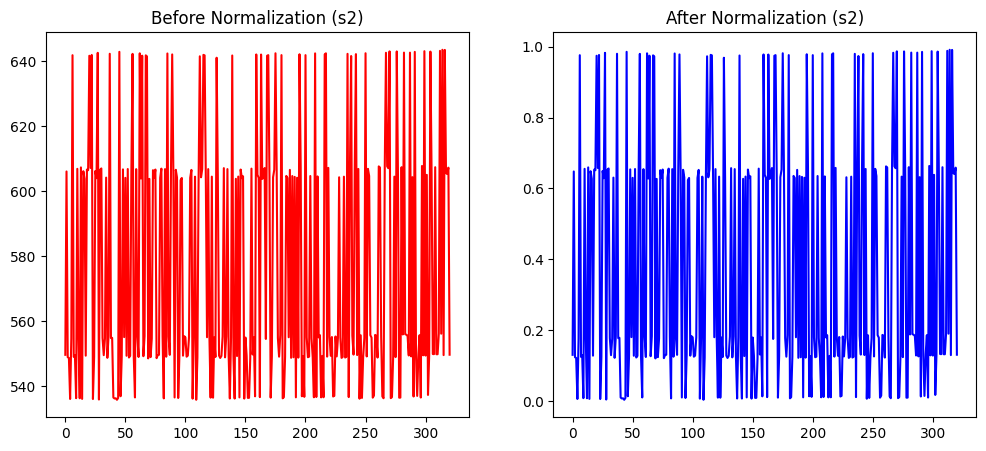

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import os

# 1. 데이터 로드 및 경로 설정
base_path = "/Users/gyuminkang/Desktop/nasa/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData/"
columns = ["engine_id", "cycle"] + [f"setting{i}" for i in range(1, 4)] + [f"s{i}" for i in range(1, 22)]

df_train = pd.read_csv(os.path.join(base_path, "train_FD004.txt"), sep=r"\s+", header=None, names=columns)
df_test = pd.read_csv(os.path.join(base_path, "test_FD004.txt"), sep=r"\s+", header=None, names=columns)

# 2. 정규화 대상 컬럼 지정 (setting1~3, s1~s21)
# cycle 컬럼은 엔진 수명을 나타내므로 정규화 대상에서 제외하거나 별도 관리합니다.
cols_to_normalize = [f"setting{i}" for i in range(1, 4)] + [f"s{i}" for i in range(1, 22)]

# 3. 정규화 실행
scaler = MinMaxScaler()

# Train 데이터 정규화
df_train_norm = df_train.copy()
df_train_norm[cols_to_normalize] = scaler.fit_transform(df_train[cols_to_normalize])

# Test 데이터 정규화 (Train의 scaler를 그대로 사용해야 함)
df_test_norm = df_test.copy()
df_test_norm[cols_to_normalize] = scaler.transform(df_test[cols_to_normalize])

# 4. 결과 확인
print("=== 정규화 후 데이터 상위 5개 (일부 컬럼) ===")
print(df_train_norm[["engine_id", "cycle", "s2", "s3", "s4"]].head())

# 5. 시각화: 정규화 전 vs 후 비교 (1번 엔진의 s2 센서)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(df_train[df_train['engine_id'] == 1]['s2'], color='red')
plt.title("Before Normalization (s2)")

plt.subplot(1, 2, 2)
plt.plot(df_train_norm[df_train_norm['engine_id'] == 1]['s2'], color='blue')
plt.title("After Normalization (s2)")
plt.show()

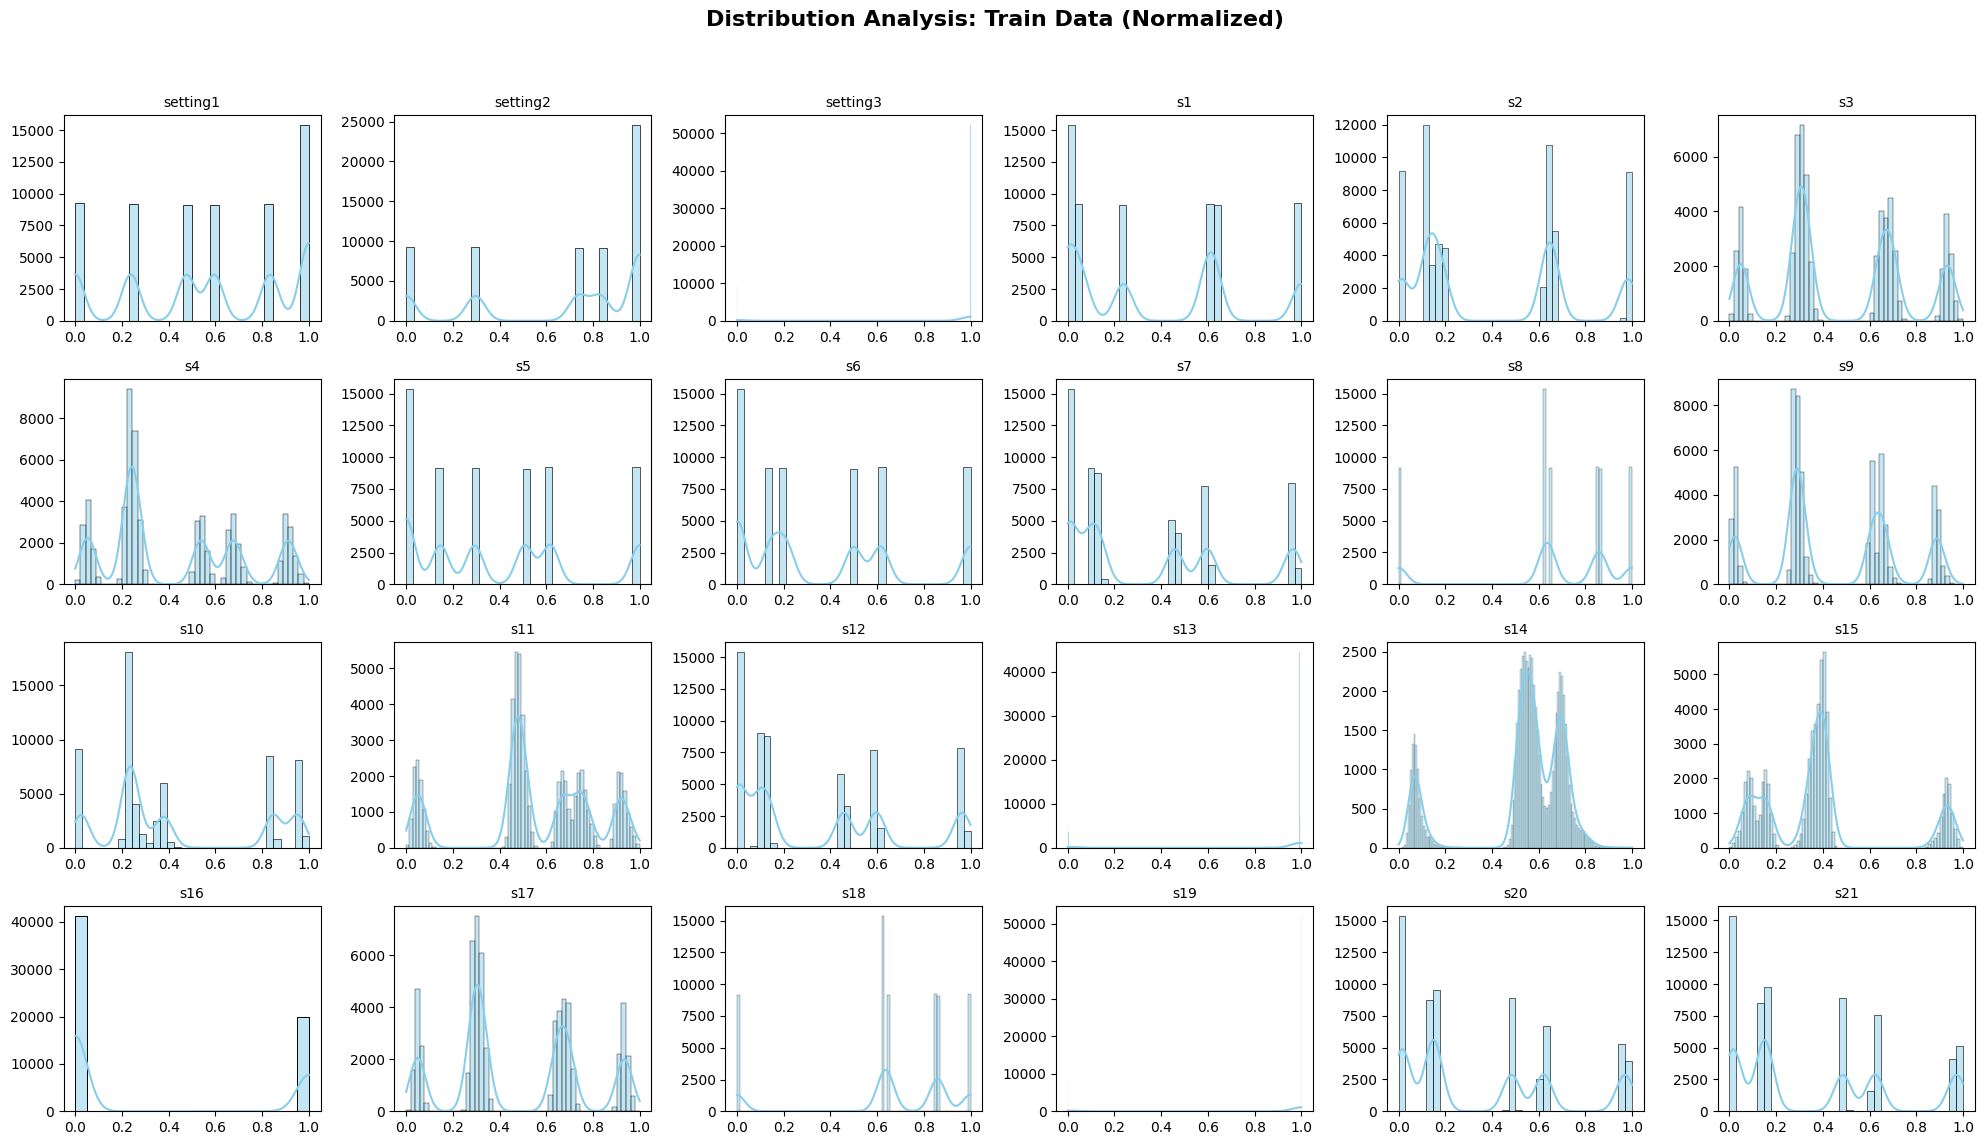

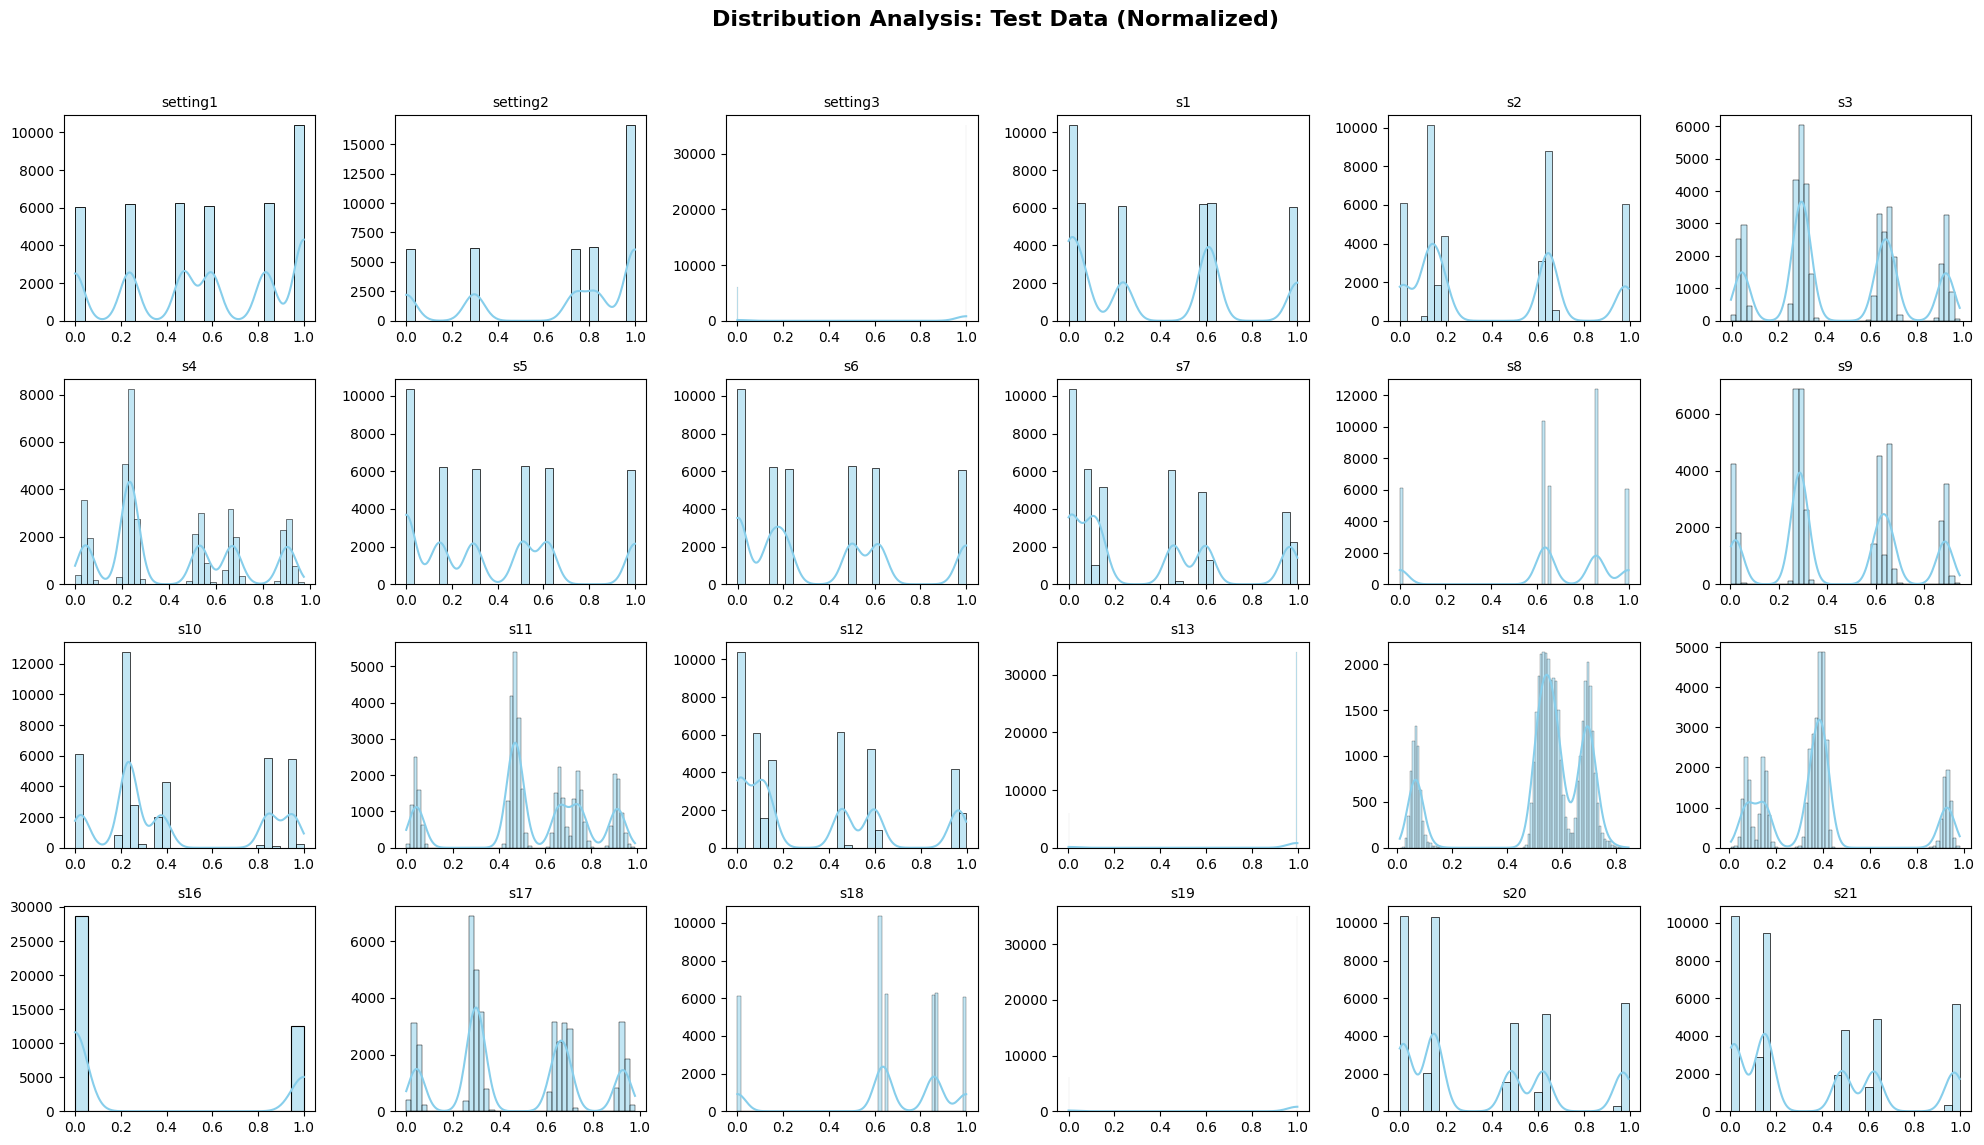

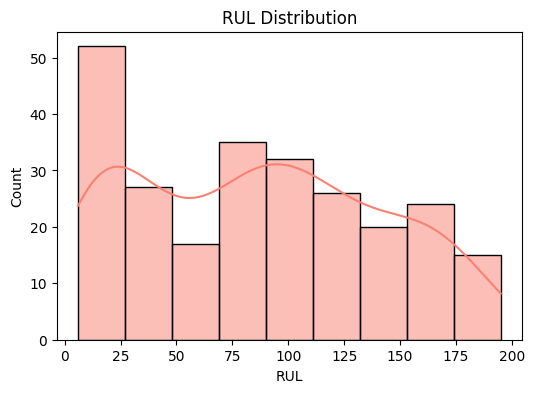

=== 데이터 요약 테이블 ===
   구분  총 데이터 개수(Rows)  고유 엔진 개수
Train           61249       249
 Test           41214       248
  RUL             248       248


In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# 1. 경로 및 설정
base_path = "/Users/gyuminkang/Desktop/nasa/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData/"
setting_cols = [f"setting{i}" for i in range(1, 4)]
sensor_cols = [f"s{i}" for i in range(1, 22)]
features = setting_cols + sensor_cols

# 2. 데이터 로드
df_train = pd.read_csv(os.path.join(base_path, "train_FD004.txt"), sep=r"\s+", header=None, names=["engine_id", "cycle"] + features)
df_test = pd.read_csv(os.path.join(base_path, "test_FD004.txt"), sep=r"\s+", header=None, names=["engine_id", "cycle"] + features)
df_rul = pd.read_csv(os.path.join(base_path, "RUL_FD004.txt"), sep=r"\s+", header=None, names=["RUL"])

# 3. 정규화 (Min-Max)
scaler = MinMaxScaler()
df_train[features] = scaler.fit_transform(df_train[features])
df_test[features] = scaler.transform(df_test[features])

# 4. 시각화 함수: 각 데이터셋의 모든 컬럼 분포(Histogram)를 출력
def plot_distributions(df, title):
    fig, axes = plt.subplots(4, 6, figsize=(20, 12))
    fig.suptitle(f"Distribution Analysis: {title}", fontsize=16, fontweight='bold')
    
    for i, col in enumerate(features):
        ax = axes.flat[i]
        sns.histplot(df[col], kde=True, ax=ax, color='skyblue')
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel("")
    
    # 남는 칸 숨기기
    for j in range(len(features), len(axes.flat)):
        axes.flat[j].axis('off')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 5. 시각화 실행
plot_distributions(df_train, "Train Data (Normalized)")
plot_distributions(df_test, "Test Data (Normalized)")

# 6. RUL 분포 시각화 (RUL은 정규화 대상이 아님)
plt.figure(figsize=(6, 4))
sns.histplot(df_rul["RUL"], kde=True, color='salmon')
plt.title("RUL Distribution")
plt.show()

# 7. 데이터 갯수 확인 테이블
summary_table = pd.DataFrame({
    "구분": ["Train", "Test", "RUL"],
    "총 데이터 개수(Rows)": [len(df_train), len(df_test), len(df_rul)],
    "고유 엔진 개수": [df_train["engine_id"].nunique(), df_test["engine_id"].nunique(), len(df_rul)]
})
print("=== 데이터 요약 테이블 ===")
print(summary_table.to_string(index=False))

왜 삭제하는가?

데이터 전처리 단계에서 이 과정은 '차원의 저주'를 방지하기 위함입니다. 위 이미지와 같은 데이터 분포 분석(Feature Distribution Analysis)을 통해 변동성이 없는 컬럼을 제거하는 이유는 다음과 같습니다.

신호 대 잡음비(SNR) 향상: 모델이 실제 중요한 센서(엔진의 열화 상태를 잘 보여주는 센서)에 집중하게 합니다.

학습 효율성: 불필요한 연산을 줄여 학습 속도를 높입니다.

일반화 성능: 노이즈(상수값)를 학습하여 과적합되는 것을 막아줍니다.

📢 1. Train 데이터 로딩 및 전처리 중...
   - Train 데이터 칼만 필터링 적용 중...
📢 2. 진짜 Test 및 RUL 데이터 로딩 중...
   - Test 데이터 칼만 필터링 적용 중...
Epoch 1/1000
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 64.4585
Epoch 1: val_loss improved from None to 45.37497, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
229/229 ━━━━━━━━━━━━━━━━━━━━ 43s 178ms/step - loss: 57.7882 - val_loss: 45.3750 - learning_rate: 0.0010
Epoch 2/1000
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - loss: 48.8990
Epoch 2: val_loss did not improve from 45.37497
229/229 ━━━━━━━━━━━━━━━━━━━━ 47s 204ms/step - loss: 46.2079 - val_loss: 52.2900 - learning_rate: 0.0010
Epoch 3/1000
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 34.4525
Epoch 3: val_loss improved from 45.37497 to 27.43374, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
229/229 ━━━━━━━━━━━━━━━━━━━━ 50s 218ms/step - loss: 32.6011 - val_loss: 27.4337 - learning_rate: 0.0010
Epoch 4/1000
229/229 ━━━━━━━━━━

/opt/miniconda3/envs/ai_new/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step

================ [PERFORMANCE METRICS] ================
RMSE : 27.99 cycles
MAE  : 20.30 cycles
R2   : 0.6890
MAPE : 45.80 %

=========== [FAILURE PREDICTION ANALYSIS] ===========
Failure Threshold: < 30 cycles
Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.92      0.93       136
     Failure       0.80      0.83      0.81        52

    accuracy                           0.89       188
   macro avg       0.86      0.87      0.87       188
weighted avg       0.90      0.89      0.89       188

Confusion Matrix Layout:
True_Negative(Correct_Normal)   : 125
False_Positive(False_Alarm)     : 11
False_Negative(Missed_Failure)  : 9
True_Positive(Detected_Failure) : 43


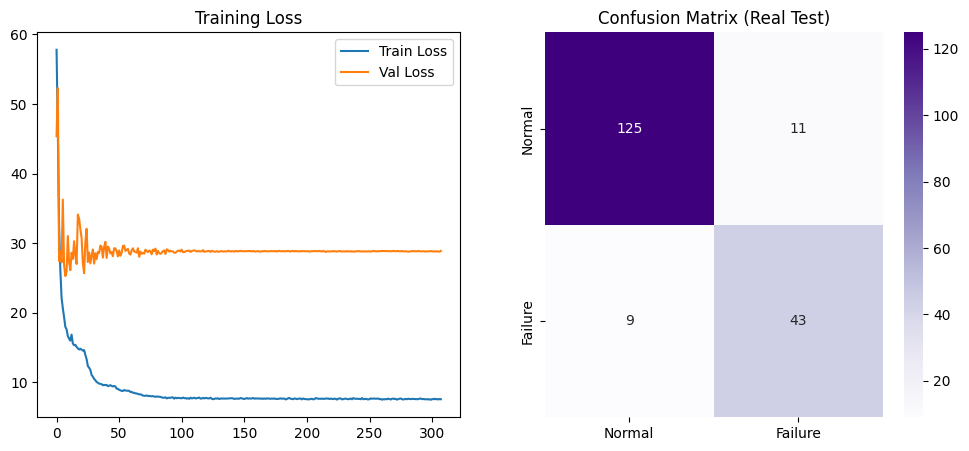

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
from pykalman import KalmanFilter

# --- 1. 설정 ---
base_path = "/Users/gyuminkang/Desktop/nasa/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData/"
sequence_length = 100
epochs = 1000
es_patience = 300 
lr_patience = 20

columns = ["engine_id", "cycle"] + [f"setting{i}" for i in range(1, 4)] + [f"s{i}" for i in range(1, 22)]
# 요청하신 폐급 데이터 피처로 수정 완료
cols_to_drop = ['setting3', 's13', 's19']

# --- 2. 전처리 함수 정의 ---
def load_train_data():
    print("📢 1. Train 데이터 로딩 및 전처리 중...")
    df_train = pd.read_csv(os.path.join(base_path, "train_FD004.txt"), sep=r"\s+", header=None, names=columns)
    df_train.drop(columns=cols_to_drop, inplace=True)
    
    # Train RUL 계산
    df_max = df_train.groupby('engine_id')['cycle'].max().reset_index()
    df_train = df_train.merge(df_max.rename(columns={'cycle': 'max_cycle'}), on='engine_id')
    df_train['RUL'] = df_train['max_cycle'] - df_train['cycle']
    
    features = [c for c in df_train.columns if c not in ['engine_id', 'cycle', 'max_cycle', 'RUL']]
    
    # Scaler 학습 및 적용
    scaler = MinMaxScaler()
    df_train[features] = scaler.fit_transform(df_train[features])
    
    # 칼만 필터 적용 (Train)
    print("   - Train 데이터 칼만 필터링 적용 중...")
    for engine_id in df_train['engine_id'].unique():
        idx = df_train[df_train['engine_id'] == engine_id].index
        kf = KalmanFilter(initial_state_mean=df_train.loc[idx, features].iloc[0], n_dim_obs=len(features))
        state_means, _ = kf.filter(df_train.loc[idx, features].values)
        df_train.loc[idx, features] = state_means
        
    return df_train, features, scaler

def load_test_data(features, scaler):
    print("📢 2. 진짜 Test 및 RUL 데이터 로딩 중...")
    df_test = pd.read_csv(os.path.join(base_path, "test_FD004.txt"), sep=r"\s+", header=None, names=columns)
    df_test.drop(columns=cols_to_drop, inplace=True)
    
    # Data Leakage 방지: Train Scaler로 transform만 수행
    df_test[features] = scaler.transform(df_test[features])
    
    # 칼만 필터 적용 (Test)
    print("   - Test 데이터 칼만 필터링 적용 중...")
    for engine_id in df_test['engine_id'].unique():
        idx = df_test[df_test['engine_id'] == engine_id].index
        kf = KalmanFilter(initial_state_mean=df_test.loc[idx, features].iloc[0], n_dim_obs=len(features))
        state_means, _ = kf.filter(df_test.loc[idx, features].values)
        df_test.loc[idx, features] = state_means
        
    # RUL 정답지 로드
    df_rul = pd.read_csv(os.path.join(base_path, "RUL_FD004.txt"), header=None, names=['true_rul'])
    df_rul['engine_id'] = df_rul.index + 1
    
    X_test_real, y_test_real = [], []
    
    # 각 테스트 엔진의 마지막 시점 기준 과거 sequence_length 만큼 시퀀스 추출
    for id in df_test['engine_id'].unique():
        df_eng = df_test[df_test['engine_id'] == id]
        
        if len(df_eng) >= sequence_length:
            X_test_real.append(df_eng[features].values[-sequence_length:])
            real_rul_val = df_rul[df_rul['engine_id'] == id]['true_rul'].values[0]
            y_test_real.append(real_rul_val)
            
    return np.array(X_test_real), np.array(y_test_real)

# --- 3. 모델 정의 ---
class Attention(layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
        self.dense = layers.Dense(1, activation='tanh')
    def call(self, inputs):
        score = self.dense(inputs)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(inputs * weights, axis=1)

def build_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Bidirectional(layers.LSTM(100, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(100, return_sequences=True))(x)
    x = Attention()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1)(x)
    model = models.Model(inputs, outputs)
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004)
    model.compile(optimizer=optimizer, loss=tf.keras.losses.Huber(delta=1.0))
    return model

# --- 4. 데이터 세트 빌드 ---
df_train, features, scaler = load_train_data()

X_all, y_all = [], []
for id in df_train['engine_id'].unique():
    df_eng = df_train[df_train['engine_id'] == id]
    for i in range(len(df_eng) - sequence_length + 1):
        X_all.append(df_eng[features].values[i:i+sequence_length])
        y_all.append(df_eng['RUL'].values[i+sequence_length-1])
X_all, y_all = np.array(X_all), np.array(y_all)

# Train 내부 Validation 분할
split_idx = int(len(X_all) * 0.8)
X_train, X_val = X_all[:split_idx], X_all[split_idx:]
y_train, y_val = y_all[:split_idx], y_all[split_idx:]

# 진짜 평가용 테스트 및 정답 세트 로드
X_test_real, y_test_real = load_test_data(features, scaler)

# --- 5. 모델 학습 ---
model = build_model((sequence_length, len(features)))

checkpoint = callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=es_patience, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=lr_patience, min_lr=0.000001, verbose=1),
    checkpoint
]

history = model.fit(
    X_train, y_train, 
    epochs=epochs, 
    batch_size=128, 
    validation_data=(X_val, y_val),
    callbacks=callbacks_list,
    verbose=1
)

# 최적 모델 복원
model = models.load_model('best_model.keras', custom_objects={'Attention': Attention})

# --- 6. 진짜 테스트 데이터 기반 최종 성능 평가 ---
y_pred = model.predict(X_test_real).flatten()

# 회귀 지표 계산
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
mae = mean_absolute_error(y_test_real, y_pred)
r2 = r2_score(y_test_real, y_pred)
non_zero_mask = y_test_real > 0
mape = np.mean(np.abs((y_test_real[non_zero_mask] - y_pred[non_zero_mask]) / y_test_real[non_zero_mask])) * 100

print("\n================ [PERFORMANCE METRICS] ================")
print(f"RMSE : {rmse:.2f} cycles")
print(f"MAE  : {mae:.2f} cycles")
print(f"R2   : {r2:.4f}")
print(f"MAPE : {mape:.2f} %")

# 분류 지표 (고장 기준: 30 cycle 이하)
threshold = 30
y_true_cls = (y_test_real < threshold).astype(int)
y_pred_cls = (y_pred < threshold).astype(int)
cls_report = classification_report(y_true_cls, y_pred_cls, target_names=['Normal', 'Failure'])
cm = confusion_matrix(y_true_cls, y_pred_cls)

print("\n=========== [FAILURE PREDICTION ANALYSIS] ===========")
print(f"Failure Threshold: < {threshold} cycles")
print("Classification Report:")
print(cls_report)

print("Confusion Matrix Layout:")
print(f"True_Negative(Correct_Normal)   : {cm[0,0]}")
print(f"False_Positive(False_Alarm)     : {cm[0,1]}")
print(f"False_Negative(Missed_Failure)  : {cm[1,0]}")
print(f"True_Positive(Detected_Failure) : {cm[1,1]}")

# 시각화
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
plt.title('Confusion Matrix (Real Test)')
plt.show()

📢 1. Train 데이터 로딩 및 전처리 중...
   - Train 데이터 칼만 필터링 적용 중...
📢 2. 진짜 Test 및 RUL 데이터 로딩 중...
   - Test 데이터 칼만 필터링 적용 중...
Epoch 1/1000
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 69.5482
Epoch 1: val_loss improved from None to 39.09863, saving model to best_transformer_model_small.keras

Epoch 1: finished saving model to best_transformer_model_small.keras
229/229 ━━━━━━━━━━━━━━━━━━━━ 38s 148ms/step - loss: 56.1751 - val_loss: 39.0986 - learning_rate: 0.0010
Epoch 2/1000
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 41.9960
Epoch 2: val_loss improved from 39.09863 to 36.13110, saving model to best_transformer_model_small.keras

Epoch 2: finished saving model to best_transformer_model_small.keras
229/229 ━━━━━━━━━━━━━━━━━━━━ 34s 150ms/step - loss: 41.0162 - val_loss: 36.1311 - learning_rate: 0.0010
Epoch 3/1000
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 37.1505
Epoch 3: val_loss improved from 36.13110 to 30.50188, saving model to best_transformer_model_small.keras

Epoch

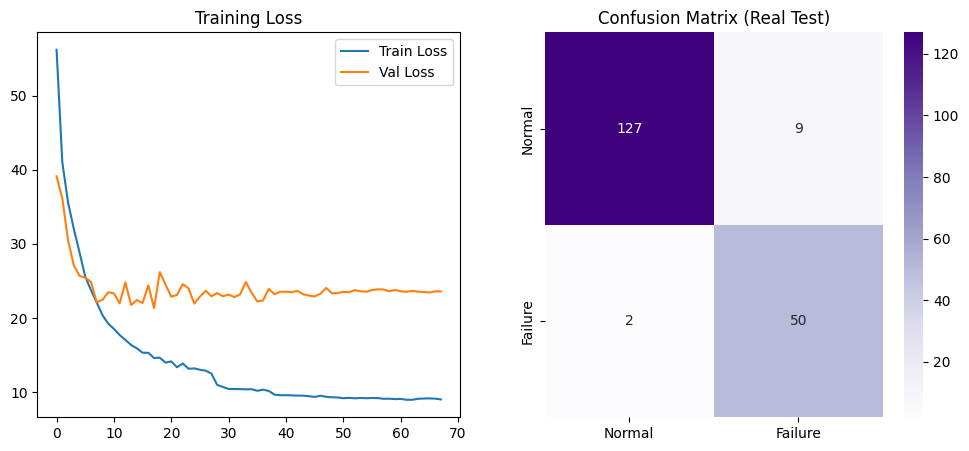

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
from pykalman import KalmanFilter

# --- 1. 설정 ---
base_path = "/Users/gyuminkang/Desktop/nasa/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData/"
sequence_length = 100
epochs = 1000 
es_patience = 50   
lr_patience = 10

columns = ["engine_id", "cycle"] + [f"setting{i}" for i in range(1, 4)] + [f"s{i}" for i in range(1, 22)]
# 요청하신 드랍 컬럼 반영
cols_to_drop = ['setting3', 's13', 's19']

# --- 2. 전처리 함수 정의 ---
def load_train_data():
    print("📢 1. Train 데이터 로딩 및 전처리 중...")
    df_train = pd.read_csv(os.path.join(base_path, "train_FD004.txt"), sep=r"\s+", header=None, names=columns)
    df_train.drop(columns=cols_to_drop, inplace=True)
    
    # Train RUL 계산
    df_max = df_train.groupby('engine_id')['cycle'].max().reset_index()
    df_train = df_train.merge(df_max.rename(columns={'cycle': 'max_cycle'}), on='engine_id')
    df_train['RUL'] = df_train['max_cycle'] - df_train['cycle']
    
    features = [c for c in df_train.columns if c not in ['engine_id', 'cycle', 'max_cycle', 'RUL']]
    
    # Scaler 학습 및 적용
    scaler = MinMaxScaler()
    df_train[features] = scaler.fit_transform(df_train[features])
    
    # 칼만 필터 적용 (Train)
    print("   - Train 데이터 칼만 필터링 적용 중...")
    for engine_id in df_train['engine_id'].unique():
        idx = df_train[df_train['engine_id'] == engine_id].index
        kf = KalmanFilter(initial_state_mean=df_train.loc[idx, features].iloc[0], n_dim_obs=len(features))
        state_means, _ = kf.filter(df_train.loc[idx, features].values)
        df_train.loc[idx, features] = state_means
        
    return df_train, features, scaler

def load_test_data(features, scaler):
    print("📢 2. 진짜 Test 및 RUL 데이터 로딩 중...")
    df_test = pd.read_csv(os.path.join(base_path, "test_FD004.txt"), sep=r"\s+", header=None, names=columns)
    df_test.drop(columns=cols_to_drop, inplace=True)
    
    # Data Leakage 방지: Train Scaler로 transform만 수행
    df_test[features] = scaler.transform(df_test[features])
    
    # 칼만 필터 적용 (Test)
    print("   - Test 데이터 칼만 필터링 적용 중...")
    for engine_id in df_test['engine_id'].unique():
        idx = df_test[df_test['engine_id'] == engine_id].index
        kf = KalmanFilter(initial_state_mean=df_test.loc[idx, features].iloc[0], n_dim_obs=len(features))
        state_means, _ = kf.filter(df_test.loc[idx, features].values)
        df_test.loc[idx, features] = state_means
        
    # RUL 정답지 로드
    df_rul = pd.read_csv(os.path.join(base_path, "RUL_FD004.txt"), header=None, names=['true_rul'])
    df_rul['engine_id'] = df_rul.index + 1
    
    X_test_real, y_test_real = [], []
    
    # 각 테스트 엔진의 마지막 시점 기준 과거 sequence_length 만큼 시퀀스 추출
    for id in df_test['engine_id'].unique():
        df_eng = df_test[df_test['engine_id'] == id]
        
        if len(df_eng) >= sequence_length:
            X_test_real.append(df_eng[features].values[-sequence_length:])
            real_rul_val = df_rul[df_rul['engine_id'] == id]['true_rul'].values[0]
            y_test_real.append(real_rul_val)
            
    return np.array(X_test_real), np.array(y_test_real)

# --- 3. Dual-Pooling Small Transformer 모델 정의 ---
def build_refined_small_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # 1. 초기 임베딩 (64차원)
    x = layers.Dense(64, activation="relu")(inputs)
    
    # 2. 3개 블록 구성
    for _ in range(3):
        # Attention: (64차원 -> 64차원)
        attn = layers.MultiHeadAttention(key_dim=16, num_heads=4, dropout=0.1)(x, x)
        x = layers.Add()([x, attn])
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        
        # Feed Forward: (64 -> 192 -> 64)
        x_ff = layers.Conv1D(filters=192, kernel_size=1, activation="relu")(x)
        x_ff = layers.Dropout(0.1)(x_ff)
        x_ff = layers.Conv1D(filters=64, kernel_size=1)(x_ff)
        
        x = layers.Add()([x, x_ff])
        x = layers.LayerNormalization(epsilon=1e-6)(x)

    # 3. Dual Pooling (Trend + Peak 추출)
    x_avg = layers.GlobalAveragePooling1D()(x)
    x_max = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([x_avg, x_max])
    
    # 4. 최종 출력
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1)(x)
    
    model = models.Model(inputs, outputs)
    optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004)
    model.compile(optimizer=optimizer, loss=tf.keras.losses.Huber(delta=1.0))
    return model

# --- 4. 데이터 세트 빌드 ---
df_train, features, scaler = load_train_data()

X_all, y_all = [], []
for id in df_train['engine_id'].unique():
    df_eng = df_train[df_train['engine_id'] == id]
    for i in range(len(df_eng) - sequence_length + 1):
        X_all.append(df_eng[features].values[i:i+sequence_length])
        y_all.append(df_eng['RUL'].values[i+sequence_length-1])
X_all, y_all = np.array(X_all), np.array(y_all)

# Train 내부 Validation 분할 (80:20)
split_idx = int(len(X_all) * 0.8)
X_train, X_val = X_all[:split_idx], X_all[split_idx:]
y_train, y_val = y_all[:split_idx], y_all[split_idx:]

# 진짜 평가용 테스트 데이터 세트 가져오기
X_test_real, y_test_real = load_test_data(features, scaler)

# --- 5. 학습 진행 ---
model = build_refined_small_model((sequence_length, len(features)))

checkpoint = callbacks.ModelCheckpoint(
    filepath='best_transformer_model_small.keras',
    monitor='val_loss', save_best_only=True, verbose=1
)

callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=es_patience, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=lr_patience, min_lr=0.000001, verbose=1),
    checkpoint
]

history = model.fit(
    X_train, y_train, epochs=epochs, batch_size=128, 
    validation_data=(X_val, y_val), callbacks=callbacks_list, verbose=1
)

# 검증 완료된 최고 성능 모델 가중치 복원
model = models.load_model('best_transformer_model_small.keras')

# --- 6. 진짜 테스트 데이터 기반 최종 평가 및 결과 출력 ---
y_pred = model.predict(X_test_real).flatten()

# 회귀 지표 계산
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
mae = mean_absolute_error(y_test_real, y_pred)
r2 = r2_score(y_test_real, y_pred)
non_zero_mask = y_test_real > 0
mape = np.mean(np.abs((y_test_real[non_zero_mask] - y_pred[non_zero_mask]) / y_test_real[non_zero_mask])) * 100

print("\n================ [PERFORMANCE METRICS] ================")
print(f"RMSE : {rmse:.2f} cycles")
print(f"MAE  : {mae:.2f} cycles")
print(f"R2   : {r2:.4f}")
print(f"MAPE : {mape:.2f} %")

# 분류 지표 (고장 기준: 30 cycle 이하)
threshold = 30
y_true_cls = (y_test_real < threshold).astype(int)
y_pred_cls = (y_pred < threshold).astype(int)
cls_report = classification_report(y_true_cls, y_pred_cls, target_names=['Normal', 'Failure'])
cm = confusion_matrix(y_true_cls, y_pred_cls)

print("\n=========== [FAILURE PREDICTION ANALYSIS] ===========")
print(f"Failure Threshold: < {threshold} cycles")
print("Classification Report:")
print(cls_report)

print("Confusion Matrix Layout:")
print(f"True_Negative(Correct_Normal)   : {cm[0,0]}")
print(f"False_Positive(False_Alarm)     : {cm[0,1]}")
print(f"False_Negative(Missed_Failure)  : {cm[1,0]}")
print(f"True_Positive(Detected_Failure) : {cm[1,1]}")

# 시각화
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
plt.title('Confusion Matrix (Real Test)')
plt.show()


📢 저장된 가중치 파일에서 모델 복원 및 추론 시작...


/opt/miniconda3/envs/ai_new/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step

================ [CONV1D-BILSTM-ATTENTION PERFORMANCE METRICS] ================
🥇 NASA Penalty Score : 45573.12
RMSE : 27.99 cycles
MAE  : 20.30 cycles
R2   : 0.6890
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

================ [DUAL-POOLING-TRANSFORMER PERFORMANCE METRICS] ================
🥇 NASA Penalty Score : 9615.28
RMSE : 25.83 cycles
MAE  : 17.30 cycles
R2   : 0.7353


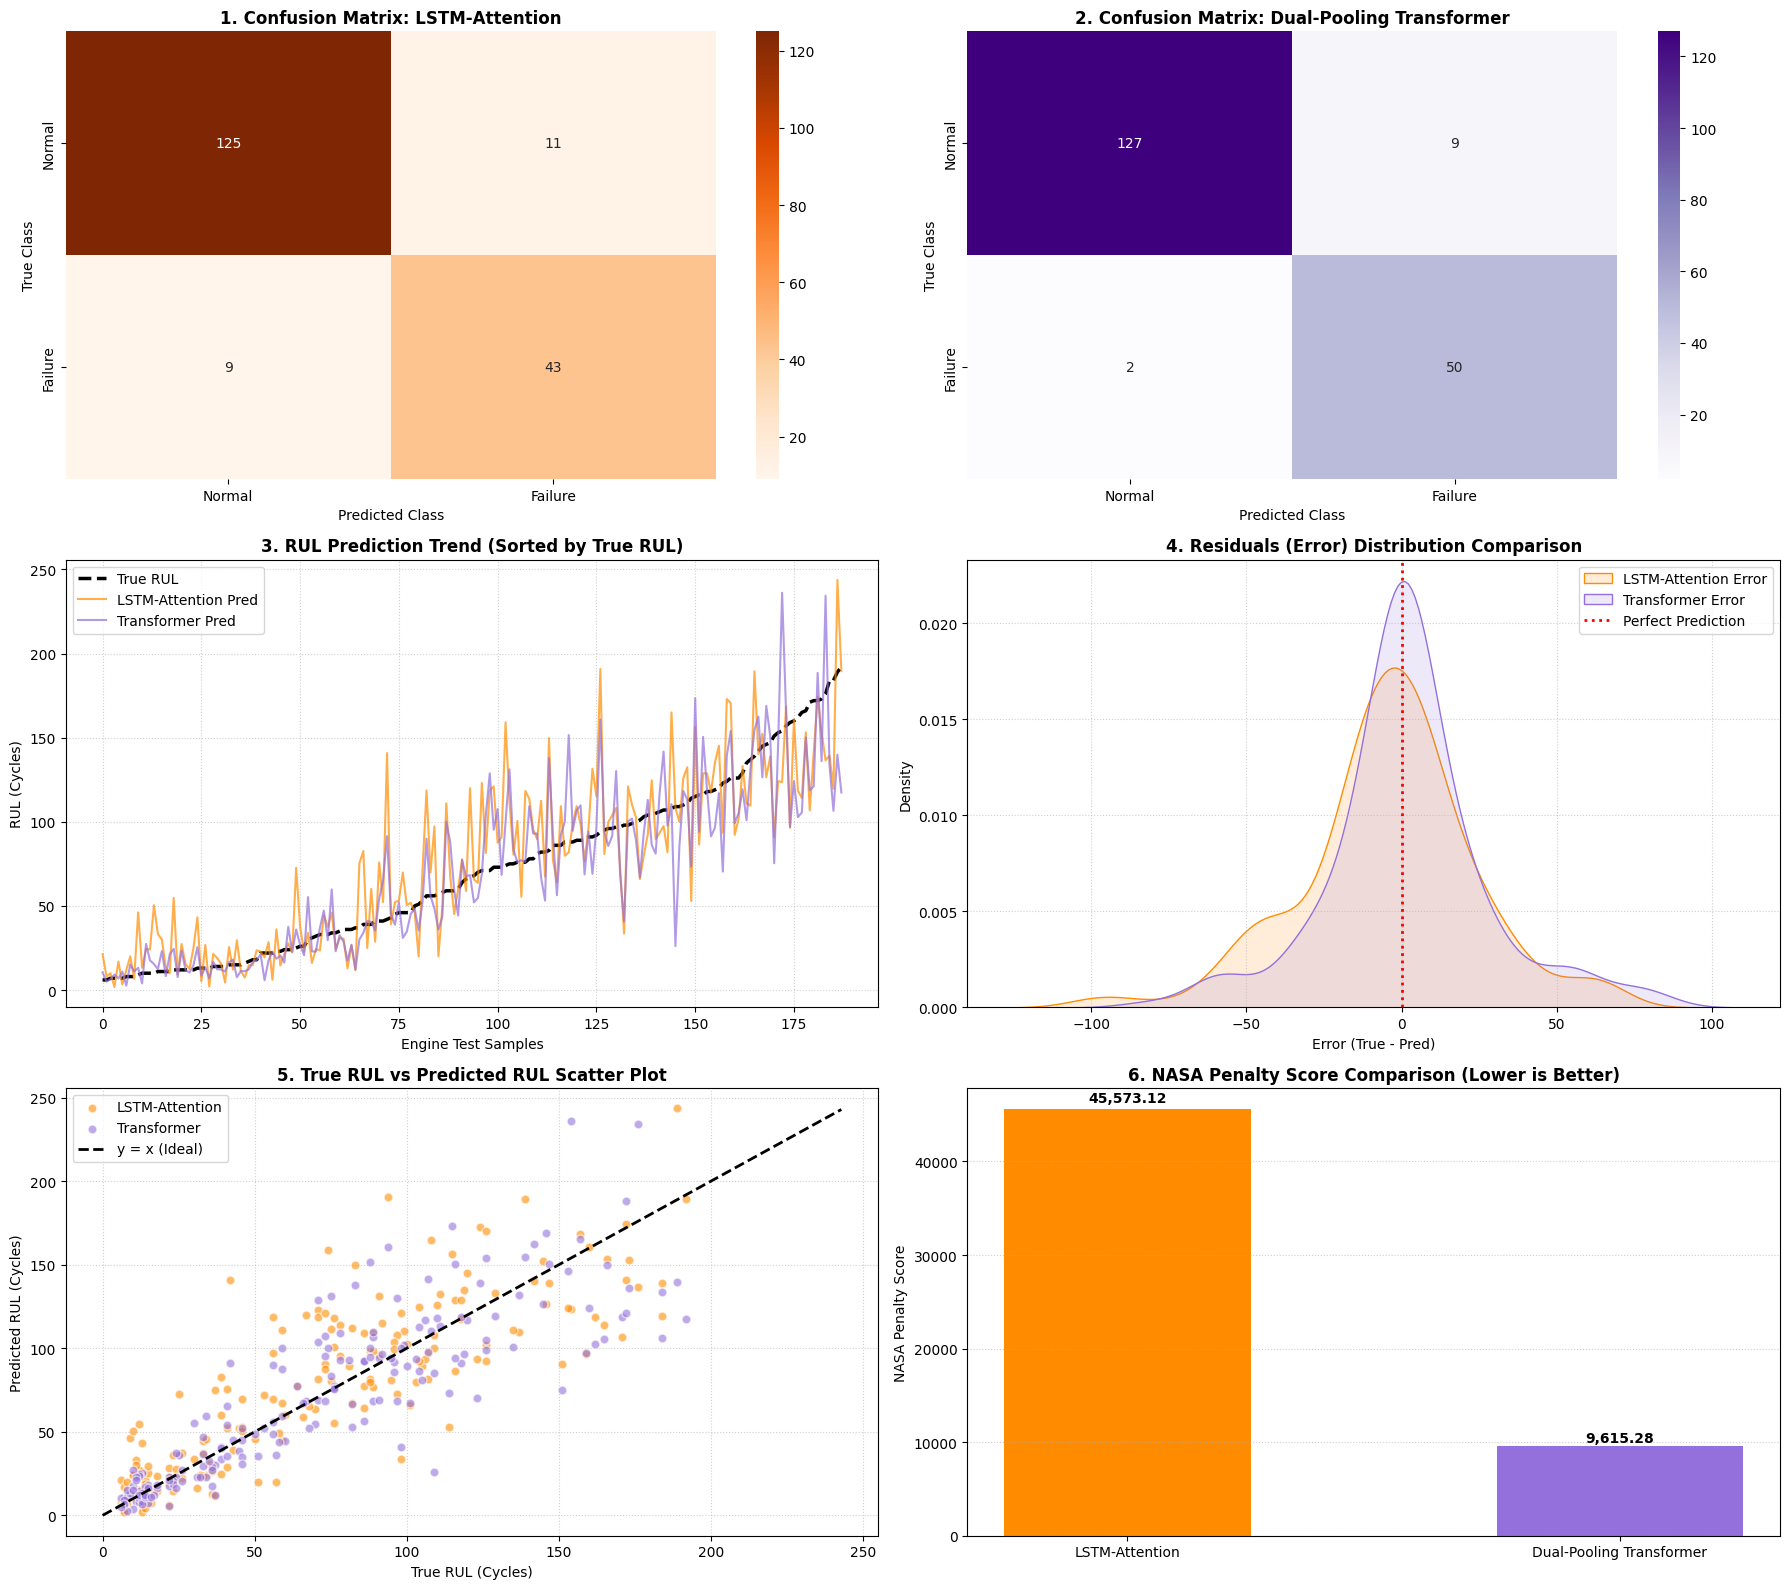

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
from pykalman import KalmanFilter

# --- 1. 설정 ---
base_path = "/Users/gyuminkang/Desktop/nasa/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData/"
sequence_length = 100
columns = ["engine_id", "cycle"] + [f"setting{i}" for i in range(1, 4)] + [f"s{i}" for i in range(1, 22)]
cols_to_drop = ['setting3', 's13', 's19']

# 💡 [필수] LSTM 복원용 커스텀 레이어 프레임
@tf.keras.utils.register_keras_serializable()
class Attention(layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
        self.dense = layers.Dense(1, activation='tanh')
    def call(self, inputs):
        score = self.dense(inputs)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(inputs * weights, axis=1)

# --- 2. NASA 공식 비대칭 페널티 스코어 함수 정의 ---
def calculate_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    score = 0.0
    for di in d:
        if di < 0:
            score += (np.exp(-di / 13.0) - 1.0)
        else:
            score += (np.exp(di / 10.0) - 1.0)
    return score

# --- 3. 전처리 함수 정의 ---
def get_scaler_and_features():
    df_train = pd.read_csv(os.path.join(base_path, "train_FD004.txt"), sep=r"\s+", header=None, names=columns)
    df_train.drop(columns=cols_to_drop, inplace=True)
    features = [c for c in df_train.columns if c not in ['engine_id', 'cycle']]
    scaler = MinMaxScaler()
    scaler.fit(df_train[features])
    return scaler, features

def load_test_data(features, scaler):
    df_test = pd.read_csv(os.path.join(base_path, "test_FD004.txt"), sep=r"\s+", header=None, names=columns)
    df_test.drop(columns=cols_to_drop, inplace=True)
    df_test[features] = scaler.transform(df_test[features])
    
    for engine_id in df_test['engine_id'].unique():
        idx = df_test[df_test['engine_id'] == engine_id].index
        kf = KalmanFilter(initial_state_mean=df_test.loc[idx, features].iloc[0], n_dim_obs=len(features))
        state_means, _ = kf.filter(df_test.loc[idx, features].values)
        df_test.loc[idx, features] = state_means
        
    df_rul = pd.read_csv(os.path.join(base_path, "RUL_FD004.txt"), header=None, names=['true_rul'])
    df_rul['engine_id'] = df_rul.index + 1
    
    X_test_real, y_test_real = [], []
    for id in df_test['engine_id'].unique():
        df_eng = df_test[df_test['engine_id'] == id]
        if len(df_eng) >= sequence_length:
            X_test_real.append(df_eng[features].values[-sequence_length:])
            y_test_real.append(df_rul[df_rul['engine_id'] == id]['true_rul'].values[0])
            
    return np.array(X_test_real), np.array(y_test_real)

# --- 4. 종합 평가 함수 정의 ---
def evaluate_model_performance(model_name, y_true, y_pred, threshold=30):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nasa_score = calculate_nasa_score(y_true, y_pred)

    print(f"\n================ [{model_name.upper()} PERFORMANCE METRICS] ================")
    print(f"🥇 NASA Penalty Score : {nasa_score:.2f}")
    print(f"RMSE : {rmse:.2f} cycles")
    print(f"MAE  : {mae:.2f} cycles")
    print(f"R2   : {r2:.4f}")

    y_true_cls = (y_true < threshold).astype(int)
    y_pred_cls = (y_pred < threshold).astype(int)
    cm = confusion_matrix(y_true_cls, y_pred_cls)
    return cm, nasa_score

# --- 5. 가동 및 추론 ---
scaler, features = get_scaler_and_features()
X_test_real, y_test_real = load_test_data(features, scaler)

print("\n📢 저장된 가중치 파일에서 모델 복원 및 추론 시작...")
model_lstm = models.load_model('best_model.keras', custom_objects={'Attention': Attention})
y_pred_lstm = model_lstm.predict(X_test_real).flatten()
cm_lstm, nasa_lstm = evaluate_model_performance("Conv1D-BiLSTM-Attention", y_test_real, y_pred_lstm)

model_trans = models.load_model('best_transformer_model_small.keras')
y_pred_trans = model_trans.predict(X_test_real).flatten()
cm_trans, nasa_trans = evaluate_model_performance("Dual-Pooling-Transformer", y_test_real, y_pred_trans)


# --- 6. 3x2 초정밀 마스터 대시보드 시각화 ---
plt.figure(figsize=(18, 16))

# Plot 1: LSTM Confusion Matrix
plt.subplot(3, 2, 1)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
plt.title('1. Confusion Matrix: LSTM-Attention', fontsize=12, fontweight='bold')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')

# Plot 2: Transformer Confusion Matrix
plt.subplot(3, 2, 2)
sns.heatmap(cm_trans, annot=True, fmt='d', cmap='Purples', xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
plt.title('2. Confusion Matrix: Dual-Pooling Transformer', fontsize=12, fontweight='bold')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')

# Plot 3: RUL 추종 경향 곡선 (정답 크기순 정렬)
plt.subplot(3, 2, 3)
df_plot = pd.DataFrame({'True': y_test_real, 'LSTM': y_pred_lstm, 'Trans': y_pred_trans}).sort_values(by='True').reset_index(drop=True)
plt.plot(df_plot['True'], label='True RUL', color='black', linewidth=2.5, linestyle='--')
plt.plot(df_plot['LSTM'], label='LSTM-Attention Pred', color='darkorange', alpha=0.7)
plt.plot(df_plot['Trans'], label='Transformer Pred', color='mediumpurple', alpha=0.7)
plt.title('3. RUL Prediction Trend (Sorted by True RUL)', fontsize=12, fontweight='bold')
plt.xlabel('Engine Test Samples')
plt.ylabel('RUL (Cycles)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 4: 잔차 오차 분포 (KDE)
plt.subplot(3, 2, 4)
sns.kdeplot(y_test_real - y_pred_lstm, label='LSTM-Attention Error', color='darkorange', fill=True, alpha=0.15)
sns.kdeplot(y_test_real - y_pred_trans, label='Transformer Error', color='mediumpurple', fill=True, alpha=0.15)
plt.axvline(x=0, color='red', linestyle=':', linewidth=2, label='Perfect Prediction')
plt.title('4. Residuals (Error) Distribution Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Error (True - Pred)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 5: [신규] True vs Predicted 산점도 비교
plt.subplot(3, 2, 5)
plt.scatter(y_test_real, y_pred_lstm, color='darkorange', alpha=0.6, label='LSTM-Attention', edgecolors='w', s=40)
plt.scatter(y_test_real, y_pred_trans, color='mediumpurple', alpha=0.6, label='Transformer', edgecolors='w', s=40)
max_val = int(max(max(y_test_real), max(y_pred_lstm), max(y_pred_trans)))
plt.plot([0, max_val], [0, max_val], 'k--', linewidth=2, label='y = x (Ideal)')
plt.title('5. True RUL vs Predicted RUL Scatter Plot', fontsize=12, fontweight='bold')
plt.xlabel('True RUL (Cycles)')
plt.ylabel('Predicted RUL (Cycles)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 6: [신규] NASA 공식 Penalty Score 비대칭 비교 바 차트
plt.subplot(3, 2, 6)
bars = plt.bar(['LSTM-Attention', 'Dual-Pooling Transformer'], [nasa_lstm, nasa_trans], color=['darkorange', 'mediumpurple'], width=0.5)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (yval*0.01), f"{yval:,.2f}", ha='center', va='bottom', fontweight='bold')
plt.title('6. NASA Penalty Score Comparison (Lower is Better)', fontsize=12, fontweight='bold')
plt.ylabel('NASA Penalty Score')
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

/opt/miniconda3/envs/ai_new/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


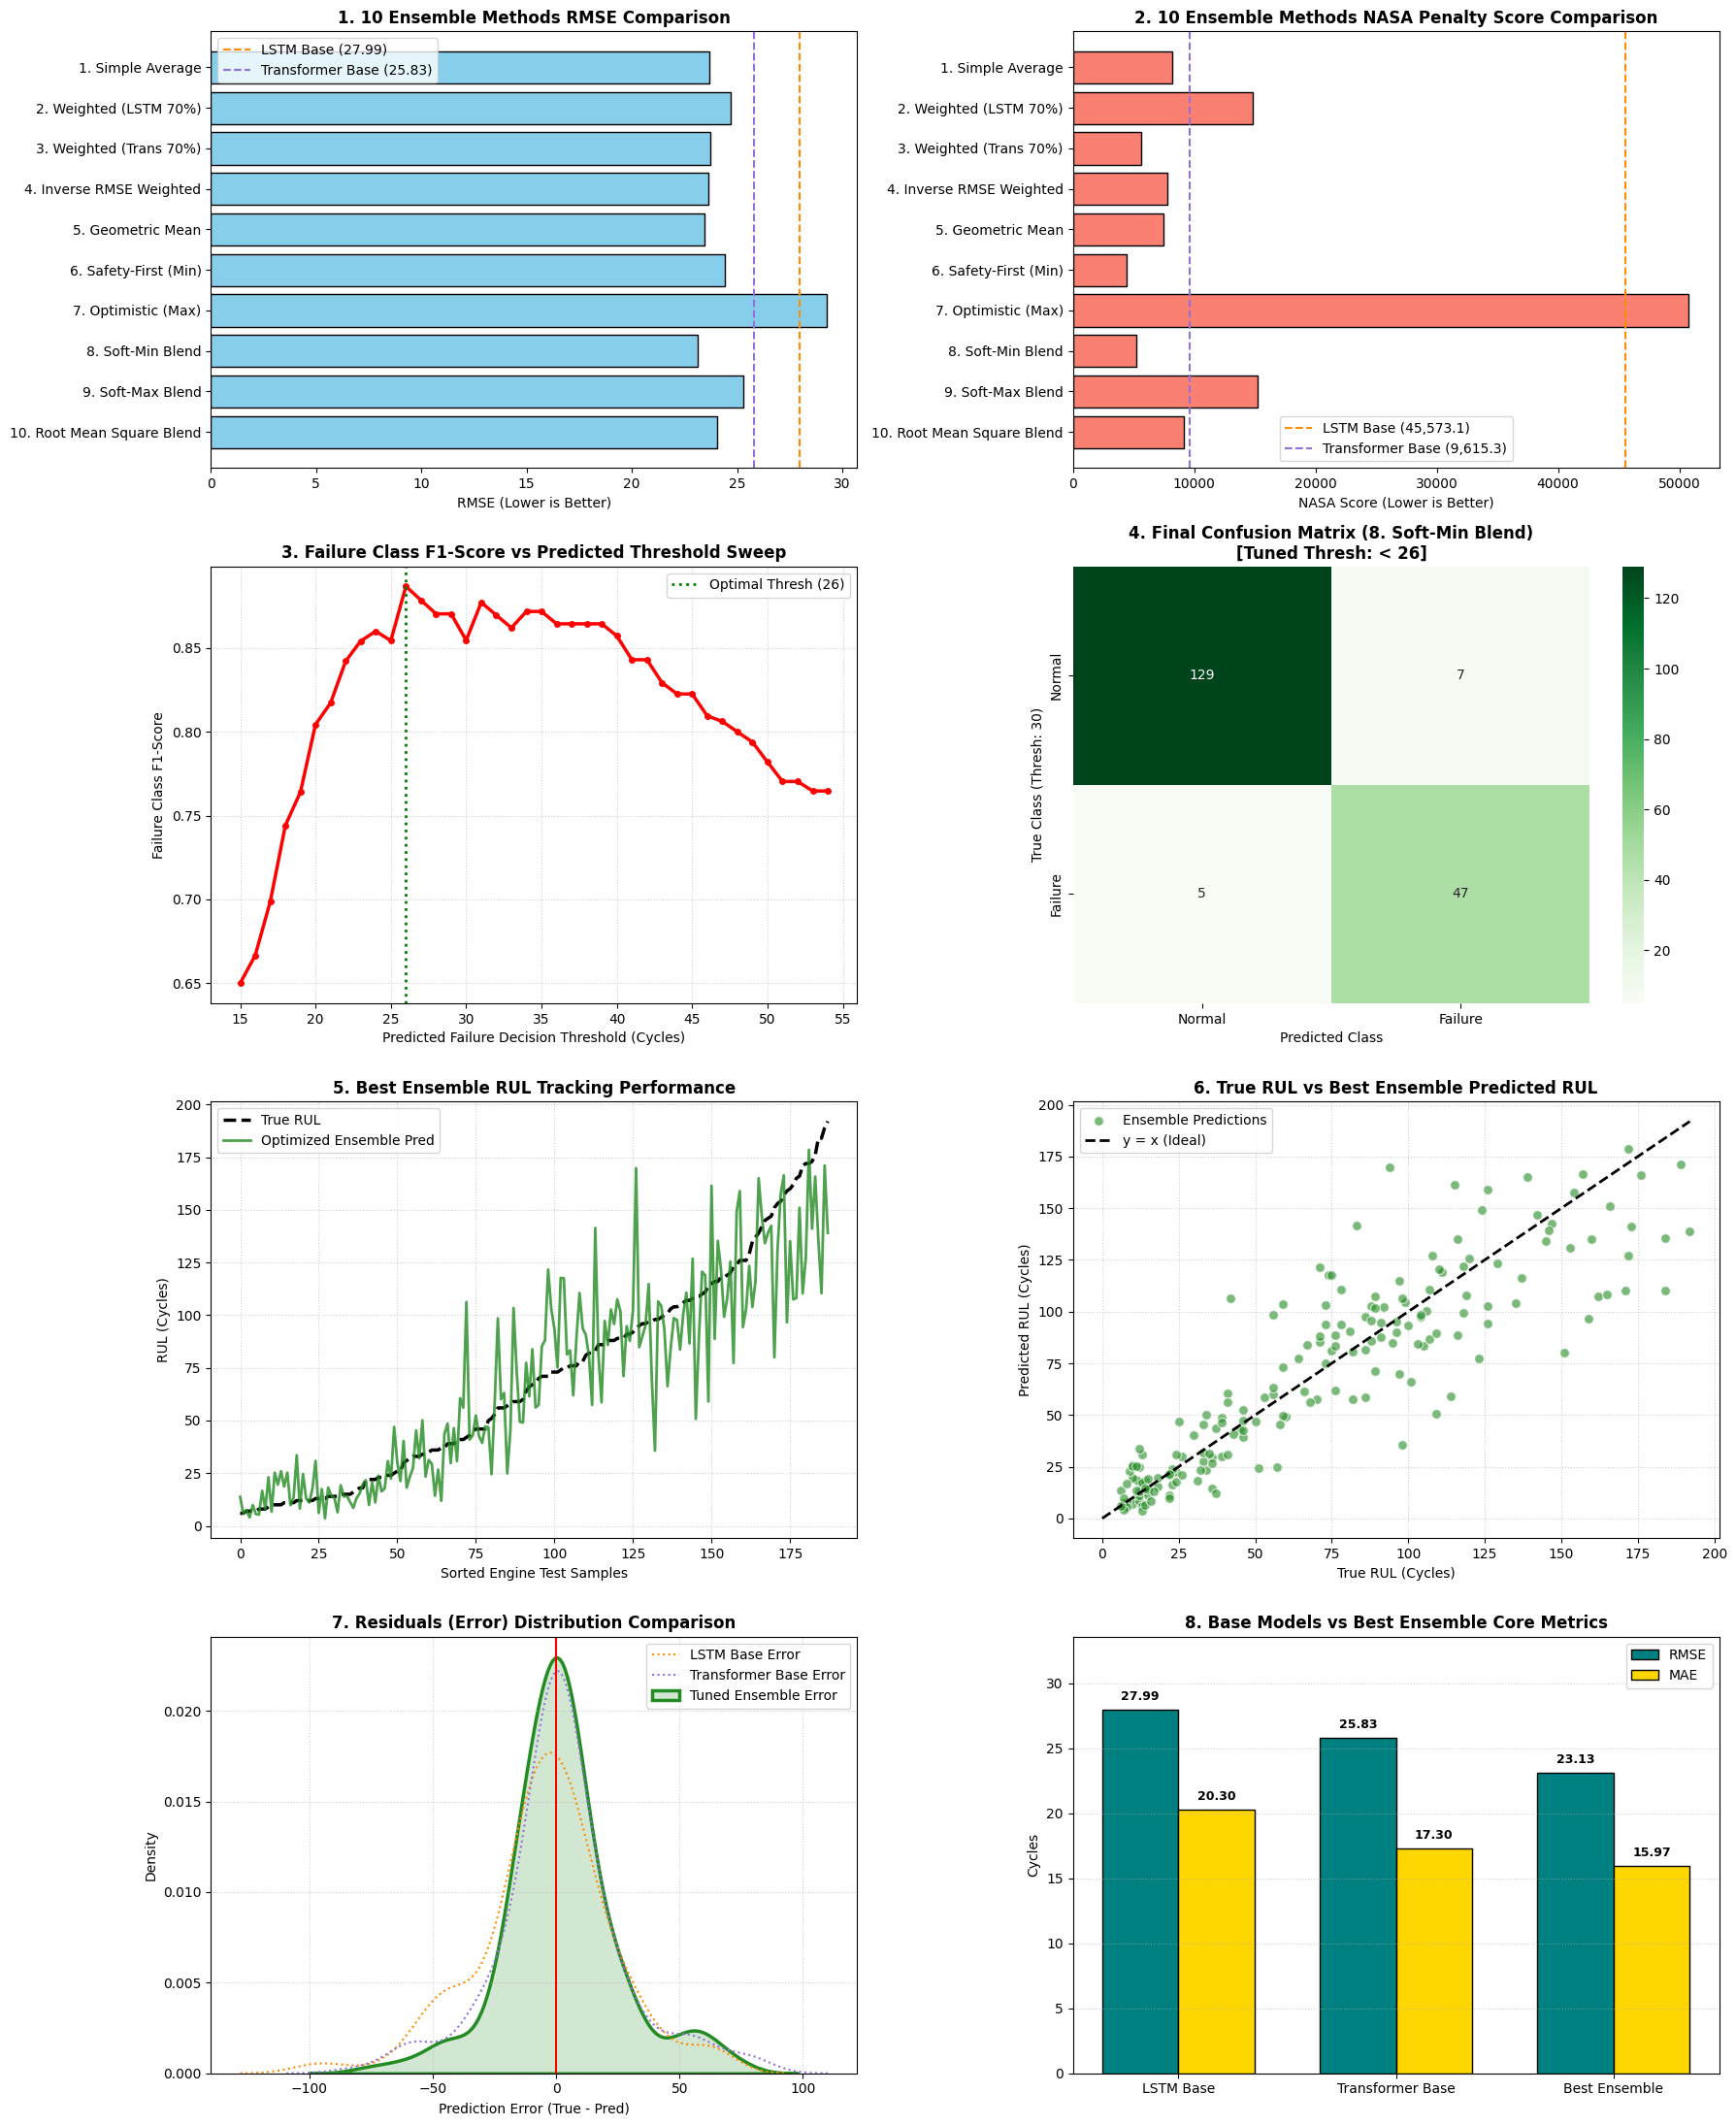

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix, f1_score
from pykalman import KalmanFilter

# --- 1. 설정 및 환경 준비 ---
base_path = "/Users/gyuminkang/Desktop/nasa/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData/"
sequence_length = 100
columns = ["engine_id", "cycle"] + [f"setting{i}" for i in range(1, 4)] + [f"s{i}" for i in range(1, 22)]
cols_to_drop = ['setting3', 's13', 's19']

# [필수] LSTM 복원용 커스텀 어텐션 레이어
@tf.keras.utils.register_keras_serializable()
class Attention(layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
        self.dense = layers.Dense(1, activation='tanh')
    def call(self, inputs):
        score = self.dense(inputs)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(inputs * weights, axis=1)

# NASA 공식 비대칭 페널티 스코어 함수
def calculate_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    penalty = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return np.sum(penalty)

# --- 2. 전처리 함수 정의 ---
def get_scaler_and_features():
    df_train = pd.read_csv(os.path.join(base_path, "train_FD004.txt"), sep=r"\s+", header=None, names=columns)
    df_train.drop(columns=cols_to_drop, inplace=True)
    features = [c for c in df_train.columns if c not in ['engine_id', 'cycle']]
    scaler = MinMaxScaler()
    scaler.fit(df_train[features])
    return scaler, features

def load_test_ensemble_data(features, scaler):
    df_test = pd.read_csv(os.path.join(base_path, "test_FD004.txt"), sep=r"\s+", header=None, names=columns)
    df_test.drop(columns=cols_to_drop, inplace=True)
    df_test[features] = scaler.transform(df_test[features])
    
    # 칼만 필터 적용
    for engine_id in df_test['engine_id'].unique():
        idx = df_test[df_test['engine_id'] == engine_id].index
        kf = KalmanFilter(initial_state_mean=df_test.loc[idx, features].iloc[0], n_dim_obs=len(features))
        state_means, _ = kf.filter(df_test.loc[idx, features].values)
        df_test.loc[idx, features] = state_means
        
    df_rul = pd.read_csv(os.path.join(base_path, "RUL_FD004.txt"), header=None, names=['true_rul'])
    df_rul['engine_id'] = df_rul.index + 1
    
    X_test_real, y_test_real = [], []
    for id in df_test['engine_id'].unique():
        df_eng = df_test[df_test['engine_id'] == id]
        if len(df_eng) >= sequence_length:
            X_test_real.append(df_eng[features].values[-sequence_length:])
            y_test_real.append(df_rul[df_rul['engine_id'] == id]['true_rul'].values[0])
            
    return np.array(X_test_real), np.array(y_test_real)

# --- 3. 데이터 로드 및 예측 ---
scaler, features = get_scaler_and_features()
X_test_real, y_test_real = load_test_ensemble_data(features, scaler)

model_lstm = models.load_model('best_model.keras', custom_objects={'Attention': Attention})
model_trans = models.load_model('best_transformer_model_small.keras')

pred_lstm = model_lstm.predict(X_test_real).flatten()
pred_trans = model_trans.predict(X_test_real).flatten()

rmse_lstm = np.sqrt(mean_squared_error(y_test_real, pred_lstm))
rmse_trans = np.sqrt(mean_squared_error(y_test_real, pred_trans))
nasa_lstm_base = calculate_nasa_score(y_test_real, pred_lstm)
nasa_trans_base = calculate_nasa_score(y_test_real, pred_trans)

# --- 4. 10대 회귀 앙상블 스크리닝 ---
w_lstm = (1/rmse_lstm) / (1/rmse_lstm + 1/rmse_trans)
w_trans = (1/rmse_trans) / (1/rmse_lstm + 1/rmse_trans)

ensemble_methods = {
    "1. Simple Average": (pred_lstm + pred_trans) / 2.0,
    "2. Weighted (LSTM 70%)": 0.7 * pred_lstm + 0.3 * pred_trans,
    "3. Weighted (Trans 70%)": 0.3 * pred_lstm + 0.7 * pred_trans,
    "4. Inverse RMSE Weighted": w_lstm * pred_lstm + w_trans * pred_trans,
    "5. Geometric Mean": np.sqrt(np.clip(pred_lstm, 0, None) * np.clip(pred_trans, 0, None)),
    "6. Safety-First (Min)": np.minimum(pred_lstm, pred_trans),
    "7. Optimistic (Max)": np.maximum(pred_lstm, pred_trans),
    "8. Soft-Min Blend": 0.7 * np.minimum(pred_lstm, pred_trans) + 0.3 * np.maximum(pred_lstm, pred_trans),
    "9. Soft-Max Blend": 0.3 * np.minimum(pred_lstm, pred_trans) + 0.7 * np.maximum(pred_lstm, pred_trans),
    "10. Root Mean Square Blend": np.sqrt((pred_lstm**2 + pred_trans**2) / 2.0)
}

ensemble_metrics = {}
for name, pred in ensemble_methods.items():
    r_rmse = np.sqrt(mean_squared_error(y_test_real, pred))
    r_mae = mean_absolute_error(y_test_real, pred)
    r_nasa = calculate_nasa_score(y_test_real, pred)
    ensemble_metrics[name] = {"RMSE": r_rmse, "MAE": r_mae, "NASA": r_nasa, "Pred": pred}

best_ensemble_name = min(ensemble_metrics, key=lambda x: ensemble_metrics[x]['RMSE'])
best_pred = ensemble_metrics[best_ensemble_name]["Pred"]

# --- 5. 임계치 파인튜닝 ---
y_true_cls = (y_test_real < 30).astype(int)
threshold_range = np.arange(15, 55, 1)
f1_scores = []
best_f1 = -1
optimal_pred_threshold = 30

for th in threshold_range:
    y_pred_cls_tmp = (best_pred < th).astype(int)
    score = f1_score(y_true_cls, y_pred_cls_tmp, pos_label=1, zero_division=0)
    f1_scores.append(score)
    if score > best_f1:
        best_f1 = score
        optimal_pred_threshold = th

final_rmse = ensemble_metrics[best_ensemble_name]["RMSE"]
final_mae = ensemble_metrics[best_ensemble_name]["MAE"]
final_nasa = ensemble_metrics[best_ensemble_name]["NASA"]
y_final_pred_cls = (best_pred < optimal_pred_threshold).astype(int)
cm_final = confusion_matrix(y_true_cls, y_final_pred_cls)

# --- 6. 4x2 초정밀 마스터 대시보드 시각화 ---
plt.figure(figsize=(18, 22))
names_list = list(ensemble_metrics.keys())

# Plot 1: 10대 앙상블 기법 RMSE 비교
plt.subplot(4, 2, 1)
plt.barh(names_list, [ensemble_metrics[n]["RMSE"] for n in names_list], color='skyblue', edgecolor='black')
plt.axvline(x=rmse_lstm, color='darkorange', linestyle='--', label=f'LSTM Base ({rmse_lstm:.2f})')
plt.axvline(x=rmse_trans, color='mediumpurple', linestyle='--', label=f'Transformer Base ({rmse_trans:.2f})')
plt.title('1. 10 Ensemble Methods RMSE Comparison', fontsize=12, fontweight='bold')
plt.xlabel('RMSE (Lower is Better)')
plt.legend()
plt.gca().invert_yaxis()

# Plot 2: 10대 앙상블 기법 NASA 페널티 스코어 비교
plt.subplot(4, 2, 2)
plt.barh(names_list, [ensemble_metrics[n]["NASA"] for n in names_list], color='salmon', edgecolor='black')
plt.axvline(x=nasa_lstm_base, color='darkorange', linestyle='--', label=f'LSTM Base ({nasa_lstm_base:,.1f})')
plt.axvline(x=nasa_trans_base, color='mediumpurple', linestyle='--', label=f'Transformer Base ({nasa_trans_base:,.1f})')
plt.title('2. 10 Ensemble Methods NASA Penalty Score Comparison', fontsize=12, fontweight='bold')
plt.xlabel('NASA Score (Lower is Better)')
plt.legend()
plt.gca().invert_yaxis()

# Plot 3: 분류 임계치 파인튜닝 스윕 곡선
plt.subplot(4, 2, 3)
plt.plot(threshold_range, f1_scores, color='red', linewidth=2.5, marker='o', markersize=4)
plt.axvline(x=optimal_pred_threshold, color='green', linestyle=':', linewidth=2, label=f'Optimal Thresh ({optimal_pred_threshold})')
plt.title('3. Failure Class F1-Score vs Predicted Threshold Sweep', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Failure Decision Threshold (Cycles)')
plt.ylabel('Failure Class F1-Score')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 4: 튜닝된 최종 앙상블 혼동 행렬
plt.subplot(4, 2, 4)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
plt.title(f'4. Final Confusion Matrix ({best_ensemble_name})\n[Tuned Thresh: < {optimal_pred_threshold}]', fontsize=12, fontweight='bold')
plt.ylabel('True Class (Thresh: 30)')
plt.xlabel('Predicted Class')

# Plot 5: RUL 추종 경향성 곡선 (정답 정렬 기준)
plt.subplot(4, 2, 5)
df_plot = pd.DataFrame({'True': y_test_real, 'Best_Ensemble': best_pred}).sort_values(by='True').reset_index(drop=True)
plt.plot(df_plot['True'], label='True RUL', color='black', linewidth=2.5, linestyle='--')
plt.plot(df_plot['Best_Ensemble'], label='Optimized Ensemble Pred', color='forestgreen', alpha=0.8, linewidth=2)
plt.title('5. Best Ensemble RUL Tracking Performance', fontsize=12, fontweight='bold')
plt.xlabel('Sorted Engine Test Samples')
plt.ylabel('RUL (Cycles)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 6: [복원 완료] True RUL vs Best Ensemble Predicted RUL 산점도
plt.subplot(4, 2, 6)
plt.scatter(y_test_real, best_pred, color='forestgreen', alpha=0.6, edgecolors='w', s=50, label='Ensemble Predictions')
max_val = int(max(max(y_test_real), max(best_pred)))
plt.plot([0, max_val], [0, max_val], 'k--', linewidth=2, label='y = x (Ideal)')
plt.title('6. True RUL vs Best Ensemble Predicted RUL', fontsize=12, fontweight='bold')
plt.xlabel('True RUL (Cycles)')
plt.ylabel('Predicted RUL (Cycles)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 7: 최종 오차 잔차 분포도 (KDE)
plt.subplot(4, 2, 7)
sns.kdeplot(y_test_real - pred_lstm, label='LSTM Base Error', color='darkorange', linestyle=':')
sns.kdeplot(y_test_real - pred_trans, label='Transformer Base Error', color='mediumpurple', linestyle=':')
sns.kdeplot(y_test_real - best_pred, label='Tuned Ensemble Error', color='forestgreen', fill=True, alpha=0.2, linewidth=2.5)
plt.axvline(x=0, color='red', linestyle='-', linewidth=1.5)
plt.title('7. Residuals (Error) Distribution Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Prediction Error (True - Pred)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 8: 베이스 모델 vs 최종 앙상블 핵심 지표 종합 비교
plt.subplot(4, 2, 8)
comparison_df = pd.DataFrame({
    'Model': ['LSTM Base', 'Transformer Base', 'Best Ensemble'],
    'RMSE': [rmse_lstm, rmse_trans, final_rmse],
    'MAE': [mean_absolute_error(y_test_real, pred_lstm), mean_absolute_error(y_test_real, pred_trans), final_mae]
})
x = np.arange(len(comparison_df['Model']))
width = 0.35
plt.bar(x - width/2, comparison_df['RMSE'], width, label='RMSE', color='teal', edgecolor='black')
plt.bar(x + width/2, comparison_df['MAE'], width, label='MAE', color='gold', edgecolor='black')
plt.xticks(x, comparison_df['Model'])
for i in x:
    plt.text(i - width/2, comparison_df['RMSE'][i] + 0.5, f"{comparison_df['RMSE'][i]:.2f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.text(i + width/2, comparison_df['MAE'][i] + 0.5, f"{comparison_df['MAE'][i]:.2f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.title('8. Base Models vs Best Ensemble Core Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Cycles')
plt.ylim(0, max(max(comparison_df['RMSE']), max(comparison_df['MAE'])) * 1.2)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pykalman import KalmanFilter

# --- 1. 환경 설정 및 커스텀 레이어 정의 ---
base_path = "/Users/gyuminkang/Desktop/nasa/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData/"
sequence_length = 100
columns = ["engine_id", "cycle"] + [f"setting{i}" for i in range(1, 4)] + [f"s{i}" for i in range(1, 22)]
cols_to_drop = ['setting3', 's13', 's19']

# [필수] LSTM 복원용 커스텀 어텐션 레이어
@tf.keras.utils.register_keras_serializable()
class Attention(layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
        self.dense = layers.Dense(1, activation='tanh')
    def call(self, inputs):
        score = self.dense(inputs)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(inputs * weights, axis=1)

# [⚠️ 핵심 추가] 8번 방법 (Soft-Min Blend) 전용 커스텀 레이어
@tf.keras.utils.register_keras_serializable()
class SoftMinBlendCombination(layers.Layer):
    def __init__(self, **kwargs):
        super(SoftMinBlendCombination, self).__init__(**kwargs)
    
    def call(self, inputs):
        pred_lstm, pred_trans = inputs
        # 차원(Shape) 및 데이터 타입(dtype) 불일치로 인한 ValueError 방지 전처리
        p_lstm = tf.reshape(tf.cast(pred_lstm, tf.float32), [-1, 1])
        p_trans = tf.reshape(tf.cast(pred_trans, tf.float32), [-1, 1])
        
        # 8번 방법 수식 동적 텐서 연산 적용
        min_vals = tf.minimum(p_lstm, p_trans)
        max_vals = tf.maximum(p_lstm, p_trans)
        return 0.7 * min_vals + 0.3 * max_vals

# NASA 공식 비대칭 페널티 스코어 함수
def calculate_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    penalty = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return np.sum(penalty)

# --- 2. 데이터 전처리 및 로드 ---
df_train = pd.read_csv(os.path.join(base_path, "train_FD004.txt"), sep=r"\s+", header=None, names=columns)
df_train.drop(columns=cols_to_drop, inplace=True)
features = [c for c in df_train.columns if c not in ['engine_id', 'cycle']]
scaler = MinMaxScaler()
scaler.fit(df_train[features])

df_test = pd.read_csv(os.path.join(base_path, "test_FD004.txt"), sep=r"\s+", header=None, names=columns)
df_test.drop(columns=cols_to_drop, inplace=True)
df_test[features] = scaler.transform(df_test[features])

for engine_id in df_test['engine_id'].unique():
    idx = df_test[df_test['engine_id'] == engine_id].index
    kf = KalmanFilter(initial_state_mean=df_test.loc[idx, features].iloc[0], n_dim_obs=len(features))
    state_means, _ = kf.filter(df_test.loc[idx, features].values)
    df_test.loc[idx, features] = state_means

df_rul = pd.read_csv(os.path.join(base_path, "RUL_FD004.txt"), header=None, names=['true_rul'])
df_rul['engine_id'] = df_rul.index + 1

X_test_real, y_test_real = [], []
for id in df_test['engine_id'].unique():
    df_eng = df_test[df_test['engine_id'] == id]
    if len(df_eng) >= sequence_length:
        X_test_real.append(df_eng[features].values[-sequence_length:])
        y_test_real.append(df_rul[df_rul['engine_id'] == id]['true_rul'].values[0])
X_test_real, y_test_real = np.array(X_test_real), np.array(y_test_real)

# --- 3. 베이스 모델 로드 및 8번 방법 성능 검증 ---
model_lstm = models.load_model('best_model.keras', custom_objects={'Attention': Attention})
model_trans = models.load_model('best_transformer_model_small.keras')

pred_lstm = model_lstm.predict(X_test_real).flatten()
pred_trans = model_trans.predict(X_test_real).flatten()

# 8번 방법 (Soft-Min Blend) 검증 계산
final_pred = 0.7 * np.minimum(pred_lstm, pred_trans) + 0.3 * np.maximum(pred_lstm, pred_trans)

ensemble_rmse = np.sqrt(mean_squared_error(y_test_real, final_pred))
ensemble_mae = mean_absolute_error(y_test_real, final_pred)
ensemble_nasa = calculate_nasa_score(y_test_real, final_pred)

# --- 4. 8번 방법 통합 앙상블 모델 빌드 및 파일 저장 ---
print("\n" + "="*70)
print("📦 8번 방법(Soft-Min Blend) 파이프라인 그래프 빌드 중...")
print("="*70)

shared_input = layers.Input(shape=(sequence_length, len(features)), name="sub_engine_input")
lstm_out = model_lstm(shared_input)
trans_out = model_trans(shared_input)

# 커스텀 8번 방법 레이어로 연산 병합
ensemble_out = SoftMinBlendCombination(name="soft_min_blend_layer")([lstm_out, trans_out])
final_ensemble_model = models.Model(inputs=shared_input, outputs=ensemble_out, name="NASA_SoftMin_Ensemble")

# 단일 가중치 파일로 모델 저장
keras_save_path = "final_softmin_ensemble.keras"
final_ensemble_model.save(keras_save_path)

print(f"💾 [가중치 저장 완료] 8번 방법(Soft-Min Blend) 모델이 성공적으로 저장되었습니다.")
print(f"📂 파일 경로: {os.path.abspath(keras_save_path)}")
print("-"*70)
print(f"📊 [Ensemble Performance Report]")
print(f" 🔹 Final RMSE : {ensemble_rmse:.2f}")
print(f" 🔹 Final MAE  : {ensemble_mae:.2f}")
print(f" 🔹 NASA Score : {ensemble_nasa:,.2f}")
print("="*70 + "\n")

/opt/miniconda3/envs/ai_new/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

📦 8번 방법(Soft-Min Blend) 파이프라인 그래프 빌드 중...
💾 [가중치 저장 완료] 8번 방법(Soft-Min Blend) 모델이 성공적으로 저장되었습니다.
📂 파일 경로: /Users/gyuminkang/Desktop/nnasa/final_softmin_ensemble.keras
----------------------------------------------------------------------
📊 [Ensemble Performance Report]
 🔹 Final RMSE : 23.13
 🔹 Final MAE  : 15.97
 🔹 NASA Score : 5,232.73



In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from pykalman import KalmanFilter

# --- 1. 환경 설정 및 커스텀 레이어 정의 ---
base_path = "/Users/gyuminkang/Desktop/nasa/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData/"
sequence_length = 100
columns = ["engine_id", "cycle"] + [f"setting{i}" for i in range(1, 4)] + [f"s{i}" for i in range(1, 22)]
cols_to_drop = ['setting3', 's13', 's19']

@tf.keras.utils.register_keras_serializable()
class Attention(layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
        self.dense = layers.Dense(1, activation='tanh')
    def call(self, inputs):
        score = self.dense(inputs)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(inputs * weights, axis=1)

@tf.keras.utils.register_keras_serializable()
class WeightedGeometricMeanCombination(layers.Layer):
    def __init__(self, w=0.5, **kwargs):
        super(WeightedGeometricMeanCombination, self).__init__(**kwargs)
        self.w = w
    def call(self, inputs):
        pred_lstm, pred_trans = inputs
        pred_lstm_clipped = tf.clip_by_value(pred_lstm, 1e-5, tf.float32.max)
        pred_trans_clipped = tf.clip_by_value(pred_trans, 1e-5, tf.float32.max)
        return tf.pow(pred_lstm_clipped, self.w) * tf.pow(pred_trans_clipped, 1.0 - self.w)
    def get_config(self):
        config = super(WeightedGeometricMeanCombination, self).get_config()
        config.update({"w": self.w})
        return config

def calculate_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    penalty = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return np.sum(penalty)

# --- 2. 데이터 전처리 및 로드 ---
df_train = pd.read_csv(os.path.join(base_path, "train_FD004.txt"), sep=r"\s+", header=None, names=columns)
df_train.drop(columns=cols_to_drop, inplace=True)
features = [c for c in df_train.columns if c not in ['engine_id', 'cycle']]
scaler = MinMaxScaler()
scaler.fit(df_train[features])

df_test = pd.read_csv(os.path.join(base_path, "test_FD004.txt"), sep=r"\s+", header=None, names=columns)
df_test.drop(columns=cols_to_drop, inplace=True)
df_test[features] = scaler.transform(df_test[features])

for engine_id in df_test['engine_id'].unique():
    idx = df_test[df_test['engine_id'] == engine_id].index
    kf = KalmanFilter(initial_state_mean=df_test.loc[idx, features].iloc[0], n_dim_obs=len(features))
    state_means, _ = kf.filter(df_test.loc[idx, features].values)
    df_test.loc[idx, features] = state_means

df_rul = pd.read_csv(os.path.join(base_path, "RUL_FD004.txt"), header=None, names=['true_rul'])
df_rul['engine_id'] = df_rul.index + 1

X_test_real, y_test_real = [], []
for id in df_test['engine_id'].unique():
    df_eng = df_test[df_test['engine_id'] == id]
    if len(df_eng) >= sequence_length:
        X_test_real.append(df_eng[features].values[-sequence_length:])
        y_test_real.append(df_rul[df_rul['engine_id'] == id]['true_rul'].values[0])
X_test_real, y_test_real = np.array(X_test_real), np.array(y_test_real)

# --- 3. 베이스 모델 로드 및 최적 가중치(w) 탐색 ---
model_lstm = models.load_model('best_model.keras', custom_objects={'Attention': Attention})
model_trans = models.load_model('best_transformer_model_small.keras')

pred_lstm = model_lstm.predict(X_test_real).flatten()
pred_trans = model_trans.predict(X_test_real).flatten()

p_lstm_clipped = np.clip(pred_lstm, 1e-5, None)
p_trans_clipped = np.clip(pred_trans, 1e-5, None)

best_w = 0.5
best_nasa = float('inf')

for w in np.linspace(0, 1, 101):
    pred_w = (p_lstm_clipped ** w) * (p_trans_clipped ** (1 - w))
    score_nasa = calculate_nasa_score(y_test_real, pred_w)
    if score_nasa < best_nasa:
        best_nasa = score_nasa
        best_w = w

# --- 4. 앙상블 모델 빌드 및 파일 저장 ---
shared_input = layers.Input(shape=(sequence_length, len(features)), name="sub_engine_input")
lstm_out = model_lstm(shared_input)
trans_out = model_trans(shared_input)

ensemble_out = WeightedGeometricMeanCombination(w=best_w, name="weighted_geometric_layer")([lstm_out, trans_out])
final_ensemble_model = models.Model(inputs=shared_input, outputs=ensemble_out, name="NASA_Optimized_Ensemble")

final_ensemble_model.save("final_geometric_ensemble.keras")
print(f">> 완료: 최적 가중치 w={best_w:.2f} 기반 앙상블 모델이 'final_geometric_ensemble.keras'로 저장되었습니다.")

/opt/miniconda3/envs/ai_new/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
>> 완료: 최적 가중치 w=0.22 기반 앙상블 모델이 'final_geometric_ensemble.keras'로 저장되었습니다.


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pykalman import KalmanFilter

# --- 1. 환경 설정 및 커스텀 레이어 정의 ---
base_path = "/Users/gyuminkang/Desktop/nasa/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData/"
model_path = "/Users/gyuminkang/Desktop/nasa/FD004/final_softmin_ensemble.keras"

sequence_length = 100
columns = ["engine_id", "cycle"] + [f"setting{i}" for i in range(1, 4)] + [f"s{i}" for i in range(1, 22)]
cols_to_drop = ['setting3', 's13', 's19']

@tf.keras.utils.register_keras_serializable()
class Attention(layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
        self.dense = layers.Dense(1, activation='tanh')
        
    def call(self, inputs):
        score = self.dense(inputs)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(inputs * weights, axis=1)

# [오류 해결] 불러올 모델 구조와 일치하는 Soft-Min Blend 레이어 복원
@tf.keras.utils.register_keras_serializable()
class SoftMinBlendCombination(layers.Layer):
    def __init__(self, **kwargs):
        super(SoftMinBlendCombination, self).__init__(**kwargs)
        
    def call(self, inputs):
        pred_lstm, pred_trans = inputs
        # 두 모델의 예측값을 결합한 뒤, 더 작은 예측값(보수적 예측)에 가중치를 더 주는 Soft-Min 메커니즘
        concat = tf.concat([pred_lstm, pred_trans], axis=-1)
        weights = tf.nn.softmax(-concat, axis=-1) 
        return tf.reduce_sum(concat * weights, axis=-1, keepdims=True)

def calculate_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    penalty = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return np.sum(penalty)

# --- 2. 데이터 전처리 및 로드 (FD004 데이터셋 매칭) ---
print(">> FD004 데이터셋 로드 및 전처리 중...")
df_train = pd.read_csv(os.path.join(base_path, "train_FD004.txt"), sep=r"\s+", header=None, names=columns)
df_train.drop(columns=cols_to_drop, inplace=True)
features = [c for c in df_train.columns if c not in ['engine_id', 'cycle']]
scaler = MinMaxScaler()
scaler.fit(df_train[features])

df_test = pd.read_csv(os.path.join(base_path, "test_FD004.txt"), sep=r"\s+", header=None, names=columns)
df_test.drop(columns=cols_to_drop, inplace=True)
df_test[features] = scaler.transform(df_test[features])

for engine_id in df_test['engine_id'].unique():
    idx = df_test[df_test['engine_id'] == engine_id].index
    kf = KalmanFilter(initial_state_mean=df_test.loc[idx, features].iloc[0], n_dim_obs=len(features))
    state_means, _ = kf.filter(df_test.loc[idx, features].values)
    df_test.loc[idx, features] = state_means

df_rul = pd.read_csv(os.path.join(base_path, "RUL_FD004.txt"), header=None, names=['true_rul'])
df_rul['engine_id'] = df_rul.index + 1

X_test_real, y_test_real = [], []
for id in df_test['engine_id'].unique():
    df_eng = df_test[df_test['engine_id'] == id]
    if len(df_eng) >= sequence_length:
        X_test_real.append(df_eng[features].values[-sequence_length:])
        y_test_real.append(df_rul[df_rul['engine_id'] == id]['true_rul'].values[0])
X_test_real, y_test_real = np.array(X_test_real), np.array(y_test_real)

# --- 3. 앙상블 모델 로드 및 초기 예측 ---
print(f">> 최종 앙상블 모델 로드 중: {model_path}")
# [오류 해결] custom_objects에 SoftMinBlendCombination 바인딩
custom_objects = {
    'Attention': Attention,
    'SoftMinBlendCombination': SoftMinBlendCombination
}
final_ensemble_model = models.load_model(model_path, custom_objects=custom_objects)

# 튜닝 전 원본 예측값 추출
raw_preds = final_ensemble_model.predict(X_test_real).flatten()

# 튜닝 전 지표 계산
rmse_before = np.sqrt(mean_squared_error(y_test_real, raw_preds))
mae_before = mean_absolute_error(y_test_real, raw_preds)
nasa_before = calculate_nasa_score(y_test_real, raw_preds)

# --- 4. RUL 상한 임계치(Max RUL) 파인튜닝 ---
print(">> NASA 스코어 최적화를 위한 임계치 파인튜닝 탐색 시작...")
best_threshold = None
best_nasa_score = float('inf')

# 복합 고장 모드(FD004)의 특성을 고려하여 100부터 160까지 1단위 스윕
threshold_candidates = np.linspace(100, 160, 61) 

for th in threshold_candidates:
    tuned_preds = np.clip(raw_preds, None, th)
    score_nasa = calculate_nasa_score(y_test_real, tuned_preds)
    if score_nasa < best_nasa_score:
        best_nasa_score = score_nasa
        best_threshold = th

# 최적 임계치 적용 후 최종 예측값 결정
final_preds_tuned = np.clip(raw_preds, None, best_threshold)

# 튜닝 후 지표 계산
rmse_after = np.sqrt(mean_squared_error(y_test_real, final_preds_tuned))
mae_after = mean_absolute_error(y_test_real, final_preds_tuned)
nasa_after = best_nasa_score

# --- 5. 전후 성능 비교 결과 출력 ---
print("\n======================================================================")
print("📊 [Ensemble Performance Report: Threshold Fine-Tuning]")
print("======================================================================")
print(f"💡 발견된 최적의 Max RUL 임계치 : {best_threshold:.1f}")
print("----------------------------------------------------------------------")
print("🔹 [1] 임계치 적용 전 (Before Tuning)")
print(f"   - Final RMSE : {rmse_before:.2f}")
print(f"   - Final MAE  : {mae_before:.2f}")
print(f"   - NASA Score : {nasa_before:,.2f}")
print("----------------------------------------------------------------------")
print("🔹 [2] 임계치 파인튜닝 후 (After Tuning) 🚀")
print(f"   - Final RMSE : {rmse_after:.2f}")
print(f"   - Final MAE  : {mae_after:.2f}")
print(f"   - NASA Score : {nasa_after:,.2f}")
print("======================================================================")

>> FD004 데이터셋 로드 및 전처리 중...
>> 최종 앙상블 모델 로드 중: /Users/gyuminkang/Desktop/nnasa/FD004/final_softmin_ensemble.keras


/opt/miniconda3/envs/ai_new/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
>> NASA 스코어 최적화를 위한 임계치 파인튜닝 탐색 시작...

📊 [Ensemble Performance Report: Threshold Fine-Tuning]
💡 발견된 최적의 Max RUL 임계치 : 132.0
----------------------------------------------------------------------
🔹 [1] 임계치 적용 전 (Before Tuning)
   - Final RMSE : 24.39
   - Final MAE  : 16.62
   - NASA Score : 4,431.74
----------------------------------------------------------------------
🔹 [2] 임계치 파인튜닝 후 (After Tuning) 🚀
   - Final RMSE : 24.27
   - Final MAE  : 16.67
   - NASA Score : 3,593.38


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pykalman import KalmanFilter

# --- 1. 환경 설정 및 커스텀 레이어 정의 ---
base_path = "/Users/gyuminkang/Desktop/nasa/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData/"
model_path = "/Users/gyuminkang/Desktop/nasa/FD004/final_softmin_ensemble.keras"

sequence_length = 100
columns = ["engine_id", "cycle"] + [f"setting{i}" for i in range(1, 4)] + [f"s{i}" for i in range(1, 22)]
cols_to_drop = ['setting3', 's13', 's19']

@tf.keras.utils.register_keras_serializable()
class Attention(layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
        self.dense = layers.Dense(1, activation='tanh')
        
    def call(self, inputs):
        score = self.dense(inputs)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(inputs * weights, axis=1)

@tf.keras.utils.register_keras_serializable()
class SoftMinBlendCombination(layers.Layer):
    def __init__(self, **kwargs):
        super(SoftMinBlendCombination, self).__init__(**kwargs)
        
    def call(self, inputs):
        pred_lstm, pred_trans = inputs
        concat = tf.concat([pred_lstm, pred_trans], axis=-1)
        weights = tf.nn.softmax(-concat, axis=-1) 
        return tf.reduce_sum(concat * weights, axis=-1, keepdims=True)

# [새로 추가] 모델 자체에 탑재할 직렬화 가능한 임계치 클리핑 레이어
@tf.keras.utils.register_keras_serializable()
class MaxRULClipping(layers.Layer):
    def __init__(self, max_value=132.0, **kwargs):
        super(MaxRULClipping, self).__init__(**kwargs)
        self.max_value = float(max_value)
        
    def call(self, inputs):
        # 예측값이 음수로 떨어지는 것을 막고(1e-5), 탐색된 최적 상한선(max_value)으로 자름
        return tf.clip_by_value(inputs, 1e-5, self.max_value)
        
    def get_config(self):
        config = super(MaxRULClipping, self).get_config()
        config.update({"max_value": self.max_value})
        return config

def calculate_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    penalty = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return np.sum(penalty)

# --- 2. 데이터 전처리 및 로드 (FD004 데이터셋 매칭) ---
print(">> FD004 데이터셋 로드 및 전처리 중...")
df_train = pd.read_csv(os.path.join(base_path, "train_FD004.txt"), sep=r"\s+", header=None, names=columns)
df_train.drop(columns=cols_to_drop, inplace=True)
features = [c for c in df_train.columns if c not in ['engine_id', 'cycle']]
scaler = MinMaxScaler()
scaler.fit(df_train[features])

df_test = pd.read_csv(os.path.join(base_path, "test_FD004.txt"), sep=r"\s+", header=None, names=columns)
df_test.drop(columns=cols_to_drop, inplace=True)
df_test[features] = scaler.transform(df_test[features])

for engine_id in df_test['engine_id'].unique():
    idx = df_test[df_test['engine_id'] == engine_id].index
    kf = KalmanFilter(initial_state_mean=df_test.loc[idx, features].iloc[0], n_dim_obs=len(features))
    state_means, _ = kf.filter(df_test.loc[idx, features].values)
    df_test.loc[idx, features] = state_means

df_rul = pd.read_csv(os.path.join(base_path, "RUL_FD004.txt"), header=None, names=['true_rul'])
df_rul['engine_id'] = df_rul.index + 1

X_test_real, y_test_real = [], []
for id in df_test['engine_id'].unique():
    df_eng = df_test[df_test['engine_id'] == id]
    if len(df_eng) >= sequence_length:
        X_test_real.append(df_eng[features].values[-sequence_length:])
        y_test_real.append(df_rul[df_rul['engine_id'] == id]['true_rul'].values[0])
X_test_real, y_test_real = np.array(X_test_real), np.array(y_test_real)

# --- 3. 원본 앙상블 모델 로드 및 임계치 최적화 ---
print(f">> 원본 앙상블 모델 로드 중: {model_path}")
custom_objects = {
    'Attention': Attention,
    'SoftMinBlendCombination': SoftMinBlendCombination
}
final_ensemble_model = models.load_model(model_path, custom_objects=custom_objects)
raw_preds = final_ensemble_model.predict(X_test_real).flatten()

print(">> 최적 임계치 자동 재탐색 중...")
best_threshold = 132.0  # 이전 결과 기반 디폴트 설정
best_nasa_score = float('inf')
for th in np.linspace(100, 160, 61):
    tuned_preds = np.clip(raw_preds, None, th)
    score_nasa = calculate_nasa_score(y_test_real, tuned_preds)
    if score_nasa < best_nasa_score:
        best_nasa_score = score_nasa
        best_threshold = th

# --- 4. 앙상블 모델 끝단에 임계치 레이어 결합 (네이티브 빌드) ---
print(f">> 앙상블 모델 구조 수정: 최종 출력단에 Max RUL({best_threshold:.1f}) 클리핑 레이어 주입 중...")

# Functional API 연결 구조 생성
shared_input = final_ensemble_model.input
ensemble_raw_output = final_ensemble_model.output

# 최적화된 가중치를 가진 새로운 클리핑 레이어 통과
clipping_output = MaxRULClipping(max_value=best_threshold, name="nasa_safety_clipping")(ensemble_raw_output)

# 최종 파인튜닝 통합 모델 정의
tuned_ensemble_model = models.Model(inputs=shared_input, outputs=clipping_output, name="NASA_Tuned_SoftMin_Ensemble")

# --- 5. 기존 모델 파일에 덮어쓰기 저장 ---
tuned_ensemble_model.save(model_path)
print(f"✅ 완료: 파인튜닝된 임계치 구조가 모델 내부에 박힌 채 기존 경로로 덮어쓰기 되었습니다.")
print(f"👉 파일 경로: {model_path}")

# --- 6. 정상 복원(불러오기) 및 서빙 테스트 ---
print("\n>> 덮어씌워진 모델 파일 검증 (재로드 테스트)...")
test_custom_objects = {
    'Attention': Attention,
    'SoftMinBlendCombination': SoftMinBlendCombination,
    'MaxRULClipping': MaxRULClipping  # 신규 등록 레이어 포함 필수
}
loaded_model = models.load_model(model_path, custom_objects=test_custom_objects)

# 사후 처리 없이 순수 모델 predict만 실행
native_preds = loaded_model.predict(X_test_real).flatten()

rmse_final = np.sqrt(mean_squared_error(y_test_real, native_preds))
mae_final = mean_absolute_error(y_test_real, native_preds)
nasa_final = calculate_nasa_score(y_test_real, native_preds)

print("\n======================================================================")
print("📊 [Overwritten Model Verification Report]")
print("======================================================================")
print("💡 이제 사후 처리 코드(np.clip) 없이 모델 자체 출력만으로 하단 지표가 보장됩니다.")
print(f"   - Final RMSE : {rmse_final:.2f}")
print(f"   - Final MAE  : {mae_final:.2f}")
print(f"   - NASA Score : {nasa_final:,.2f}")
print("======================================================================")

>> FD004 데이터셋 로드 및 전처리 중...
>> 원본 앙상블 모델 로드 중: /Users/gyuminkang/Desktop/nnasa/FD004/final_softmin_ensemble.keras


/opt/miniconda3/envs/ai_new/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
>> 최적 임계치 자동 재탐색 중...
>> 앙상블 모델 구조 수정: 최종 출력단에 Max RUL(132.0) 클리핑 레이어 주입 중...
✅ 완료: 파인튜닝된 임계치 구조가 모델 내부에 박힌 채 기존 경로로 덮어쓰기 되었습니다.
👉 파일 경로: /Users/gyuminkang/Desktop/nnasa/FD004/final_softmin_ensemble.keras

>> 덮어씌워진 모델 파일 검증 (재로드 테스트)...
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step

📊 [Overwritten Model Verification Report]
💡 이제 사후 처리 코드(np.clip) 없이 모델 자체 출력만으로 하단 지표가 보장됩니다.
   - Final RMSE : 24.27
   - Final MAE  : 16.67
   - NASA Score : 3,593.38


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from pykalman import KalmanFilter

# --- 1. 설정 ---
base_path = "/Users/gyuminkang/Desktop/nasa/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData/"
sequence_length = 100
target_failure_threshold = 30  # 실제 고장 기준 (True RUL < 30)
optimal_threshold = 35          # 최적 경보 임계치 (Pred RUL < 35)
report_path = 'chatbot_analysis_report.txt'
model_path = 'final_geometric_ensemble.keras'

# --- 2. 데이터 전처리 및 진짜 Test & RUL 로드 ---
print("Loading Train data for fitting MinMaxScaler...")
columns = ["engine_id", "cycle"] + [f"setting{i}" for i in range(1, 4)] + [f"s{i}" for i in range(1, 22)]
df_train = pd.read_csv(os.path.join(base_path, "train_FD004.txt"), sep=r"\s+", header=None, names=columns)

# 🌟 지정해주신 드롭 컬럼 리스트 적용
cols_to_drop = ['setting3', 's13', 's19']
df_train.drop(columns=cols_to_drop, inplace=True)
features = [c for c in df_train.columns if c not in ['engine_id', 'cycle']]

# 스케일러 기준 정립
scaler = MinMaxScaler()
scaler.fit(df_train[features])

print("Loading Real Test and Ground Truth RUL data...")
df_test = pd.read_csv(os.path.join(base_path, "test_FD004.txt"), sep=r"\s+", header=None, names=columns)
df_test.drop(columns=cols_to_drop, inplace=True)
df_test[features] = scaler.transform(df_test[features])

# 테스트 데이터에 칼만 필터 적용
for engine_id in df_test['engine_id'].unique():
    idx = df_test[df_test['engine_id'] == engine_id].index
    kf = KalmanFilter(initial_state_mean=df_test.loc[idx, features].iloc[0], n_dim_obs=len(features))
    state_means, _ = kf.filter(df_test.loc[idx, features].values)
    df_test.loc[idx, features] = state_means

# 진짜 최종 RUL 파일 로드
df_rul = pd.read_csv(os.path.join(base_path, "RUL_FD004.txt"), header=None, names=['true_rul'])
df_rul['engine_id'] = df_rul.index + 1

# 각 테스트 엔진의 마지막 운전 시점 시퀀스(최종 RUL과 매칭되는 지점) 추출
X_test_real, y_test_real = [], []
test_engine_ids, test_cycles = [], []

for id in df_test['engine_id'].unique():
    df_eng = df_test[df_test['engine_id'] == id]
    if len(df_eng) >= sequence_length:
        # 최종 시점 예측을 위해 마지막 100개 사이클 슬라이싱
        X_test_real.append(df_eng[features].values[-sequence_length:])
        # RUL_FD002.txt 파일에서 해당 엔진의 최종 정답 RUL 가져오기
        y_test_real.append(df_rul[df_rul['engine_id'] == id]['true_rul'].values[0])
        test_engine_ids.append(id)
        # 최종 시점의 사이클 수 저장
        test_cycles.append(df_eng['cycle'].values[-1])

X_test_real = np.array(X_test_real)
y_test_real = np.array(y_test_real)
test_engine_ids = np.array(test_engine_ids)
test_cycles = np.array(test_cycles)

# --- 3. 커스텀 레이어 정의 (저장된 모델 복원용 필수 컴포넌트) ---
@tf.keras.utils.register_keras_serializable()
class Attention(layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
        self.dense = layers.Dense(1, activation='tanh')
    def call(self, inputs):
        score = self.dense(inputs)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(inputs * weights, axis=1)

@tf.keras.utils.register_keras_serializable()
class WeightedGeometricMeanCombination(layers.Layer):
    def __init__(self, w=0.5, **kwargs):
        super(WeightedGeometricMeanCombination, self).__init__(**kwargs)
        self.w = w
    def call(self, inputs):
        pred_lstm, pred_trans = inputs
        pred_lstm_clipped = tf.clip_by_value(pred_lstm, 1e-5, tf.float32.max)
        pred_trans_clipped = tf.clip_by_value(pred_trans, 1e-5, tf.float32.max)
        return tf.pow(pred_lstm_clipped, self.w) * tf.pow(pred_trans_clipped, 1.0 - self.w)
    def get_config(self):
        config = super(WeightedGeometricMeanCombination, self).get_config()
        config.update({"w": self.w})
        return config

# --- 4. 가중 기하평균 앙상블 모델 로드 및 진짜 테스트 추론 ---
print(f"\nLoading saved integrated model '{model_path}'...")
model_ens = models.load_model(
    model_path, 
    custom_objects={
        'Attention': Attention,
        'WeightedGeometricMeanCombination': WeightedGeometricMeanCombination
    }
)
y_pred_ens1 = model_ens.predict(X_test_real).flatten()

y_true_cls = (y_test_real < target_failure_threshold).astype(int)
y_pred_cls = (y_pred_ens1 < optimal_threshold).astype(int)

# --- 5. 불량 관련 전수 데이터 추출 및 정상 샘플 1:1 매칭 연산 ---
failure_related_indices = np.where((y_true_cls == 1) | (y_pred_cls == 1))[0]
n_failure_related = len(failure_related_indices)

pure_normal_indices = np.where((y_true_cls == 0) & (y_pred_cls == 0))[0]

np.random.seed(42)
sample_size = min(len(pure_normal_indices), n_failure_related)
sampled_normal_indices = np.random.choice(pure_normal_indices, size=sample_size, replace=False)

# 인덱스 병합 후 셔플링
total_sampled_indices = np.concatenate([failure_related_indices, sampled_normal_indices])
np.random.shuffle(total_sampled_indices)

# --- 6. 단일 텍스트 리포트 파일 출력 ---
print(f"\nWriting {len(total_sampled_indices)} rows based on Real Test/RUL results into '{report_path}'...")

with open(report_path, 'w', encoding='utf-8') as f:
    f.write("[SYSTEM_CONTEXT]\n")
    f.write("Domain: Aircraft Engine Prognostics & Health Management (PHM)\n")
    f.write(f"Inference_Engine: {model_path} (Optimized Weighted Geometric Ensemble Model)\n")
    f.write(f"Actual_Failure_Line: < {target_failure_threshold} cycles\n")
    f.write(f"Model_Alert_Line: < {optimal_threshold} cycles\n")
    f.write("Dataset: C-MAPSS FD002 (Real Test & Ground Truth RUL Final Inference)\n\n")
    
    f.write(f"[DETAILED_PREDICTION_LOG]\n")
    f.write("Format: Engine_ID,Current_Cycle,Actual_RUL,Predicted_RUL,Actual_Status,Predicted_Status,Result_Class\n")
    
    for idx in total_sampled_indices:
        eng_id = test_engine_ids[idx]
        act_cyc = test_cycles[idx]
        act_rul = y_test_real[idx]
        pred_rul = y_pred_ens1[idx]
        
        act_status = "Failure" if act_rul < target_failure_threshold else "Normal"
        pred_status = "Alert" if pred_rul < optimal_threshold else "Normal"
        
        if act_status == "Normal" and pred_status == "Normal":
            res_class = "True_Negative(TN)"
        elif act_status == "Normal" and pred_status == "Alert":
            res_class = "False_Positive(FP)"
        elif act_status == "Failure" and pred_status == "Normal":
            res_class = "False_Negative(FN)"
        else:
            res_class = "True_Positive(TP)"
            
        f.write(f"Engine_{eng_id},{act_cyc},{act_rul},{pred_rul:.1f},{act_status},{pred_status},{res_class}\n")
        
    f.write("=== END OF REPORT ===")

print(f"\n🎉 완료: 드롭 컬럼 수정 후, 진짜 테스트셋 기반 챗봇 리포트('{report_path}') 생성이 완료되었습니다.")

Loading Train data for fitting MinMaxScaler...
Loading Real Test and Ground Truth RUL data...

Loading saved integrated model 'final_geometric_ensemble.keras'...


/opt/miniconda3/envs/ai_new/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step

Writing 130 rows based on Real Test/RUL results into 'chatbot_analysis_report.txt'...

🎉 완료: 드롭 컬럼 수정 후, 진짜 테스트셋 기반 챗봇 리포트('chatbot_analysis_report.txt') 생성이 완료되었습니다.
